In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [7]:
df.diet.nunique()

AttributeError: 'DataFrame' object has no attribute 'diet'

In [6]:
df = pd.read_csv("Housing_data.csv")
df.tail()

,Unnamed: 0,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
541,542,91500.0,4800,3,2,4,yes,yes,no,no,yes,0,no
542,543,94000.0,6000,3,2,4,yes,no,no,no,yes,0,no
543,544,103000.0,6000,3,2,4,yes,yes,no,no,yes,1,no
544,545,105000.0,6000,3,2,2,yes,yes,no,no,yes,1,no
545,546,105000.0,6000,3,1,2,yes,no,no,no,yes,1,no


In [8]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 546 entries, 0 to 545
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  546 non-null    int64  
 1   price       546 non-null    float64
 2   lotsize     546 non-null    int64  
 3   bedrooms    546 non-null    int64  
 4   bathrms     546 non-null    int64  
 5   stories     546 non-null    int64  
 6   driveway    546 non-null    str    
 7   recroom     546 non-null    str    
 8   fullbase    546 non-null    str    
 9   gashw       546 non-null    str    
 10  airco       546 non-null    str    
 11  garagepl    546 non-null    int64  
 12  prefarea    546 non-null    str    
dtypes: float64(1), int64(6), str(6)
memory usage: 55.6 KB


,Unnamed: 0,price,lotsize,bedrooms,bathrms,stories,garagepl
count,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000
mean,273.500000,68121.597070,5150.265568,2.965201,1.285714,1.807692,0.692308
std,157.760895,26702.670926,2168.158725,0.737388,0.502158,0.868203,0.861307
min,1.000000,25000.000000,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,137.250000,49125.000000,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,273.500000,62000.000000,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,409.750000,82000.000000,6360.000000,3.000000,2.000000,2.000000,1.000000
max,546.000000,190000.000000,16200.000000,6.000000,4.000000,4.000000,3.000000


In [9]:
df.isnull().sum()

Unnamed: 0    0
price         0
lotsize       0
bedrooms      0
bathrms       0
stories       0
driveway      0
recroom       0
fullbase      0
gashw         0
airco         0
garagepl      0
prefarea      0
dtype: int64

In [10]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].map({"yes": 1, "no": 0})

df.head()

,Unnamed: 0,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,1,42000.0,5850,3,1,2,yes,no,yes,no,no,1,no
1,2,38500.0,4000,2,1,1,yes,no,no,no,no,0,no
2,3,49500.0,3060,3,1,1,yes,no,no,no,no,0,no
3,4,60500.0,6650,3,1,2,yes,yes,no,no,no,0,no
4,5,61000.0,6360,2,1,1,yes,no,no,no,no,0,no


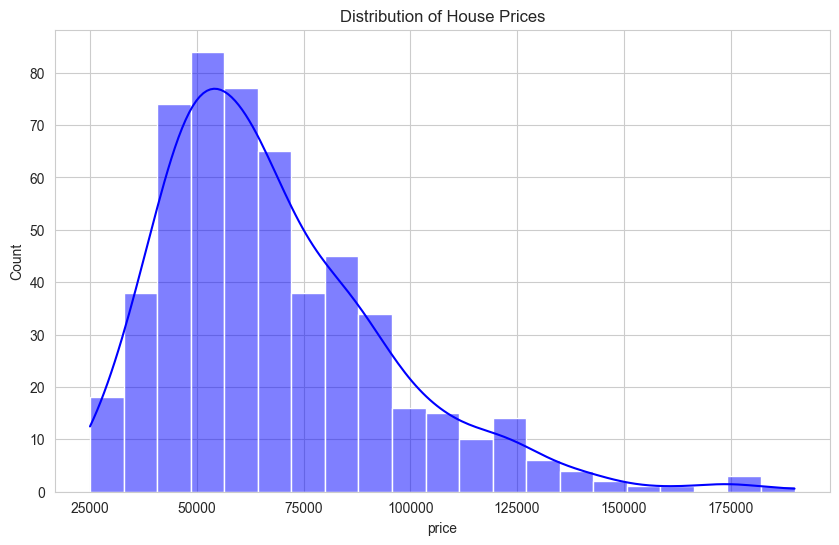

In [ ]:
sns.histplot(df["price"], kde=True, color="blue")
plt.title("Distribution of House Prices")
plt.show()

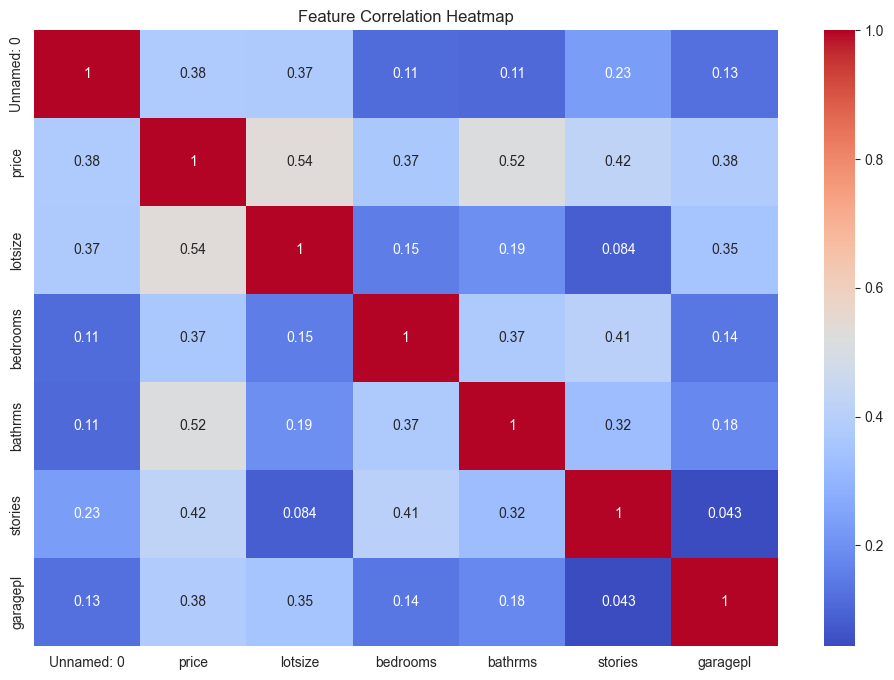

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

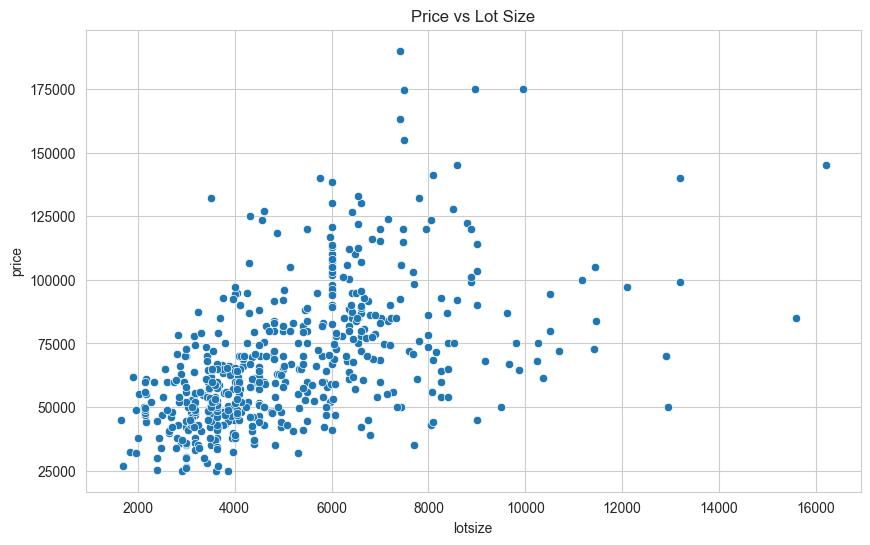

In [11]:
sns.scatterplot(x="lotsize", y="price", data=df)
plt.title("Price vs Lot Size")
plt.show()

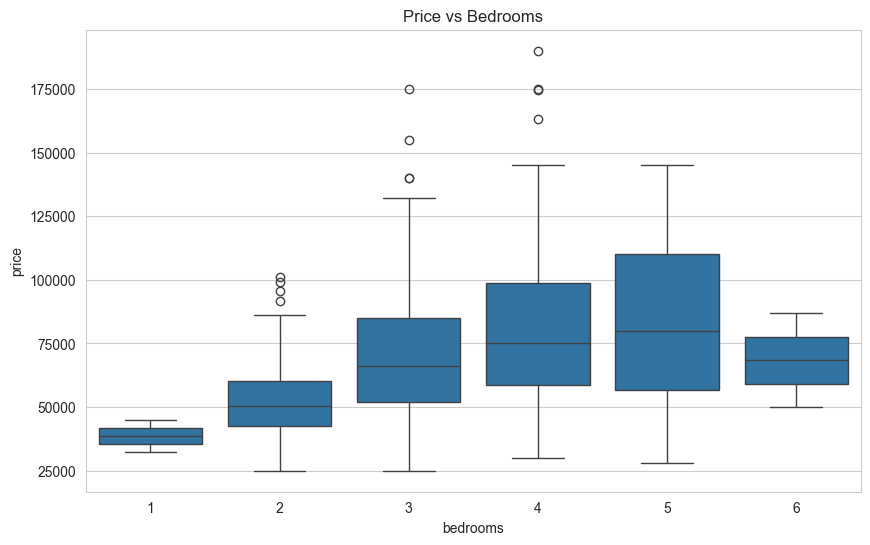

In [12]:
sns.boxplot(x="bedrooms", y="price", data=df)
plt.title("Price vs Bedrooms")
plt.show()

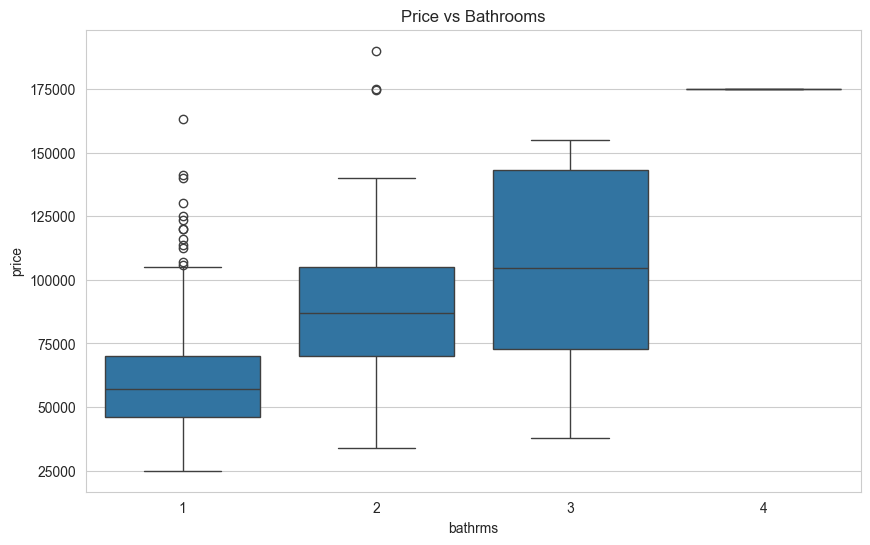

In [13]:
sns.boxplot(x="bathrms", y="price", data=df)
plt.title("Price vs Bathrooms")
plt.show()

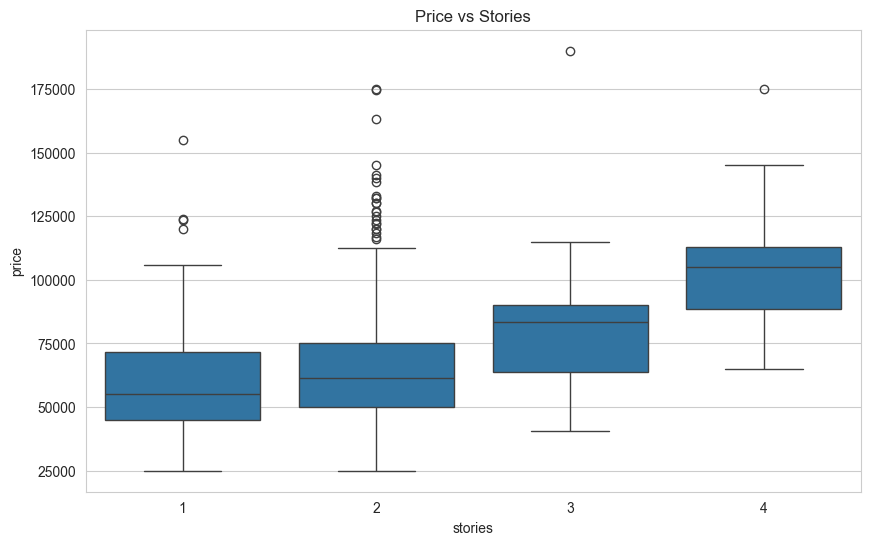

In [14]:
sns.boxplot(x="stories", y="price", data=df)
plt.title("Price vs Stories")
plt.show()

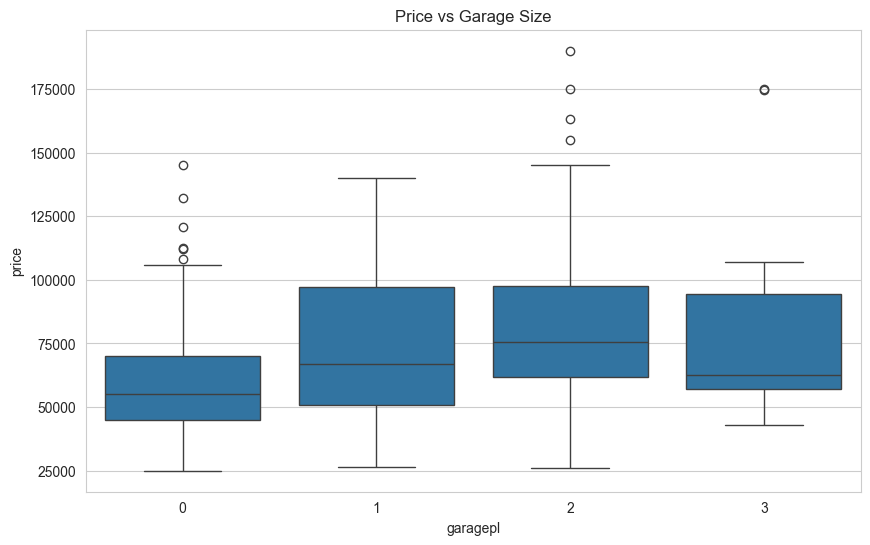

In [15]:
sns.boxplot(x="garagepl", y="price", data=df)
plt.title("Price vs Garage Size")
plt.show()

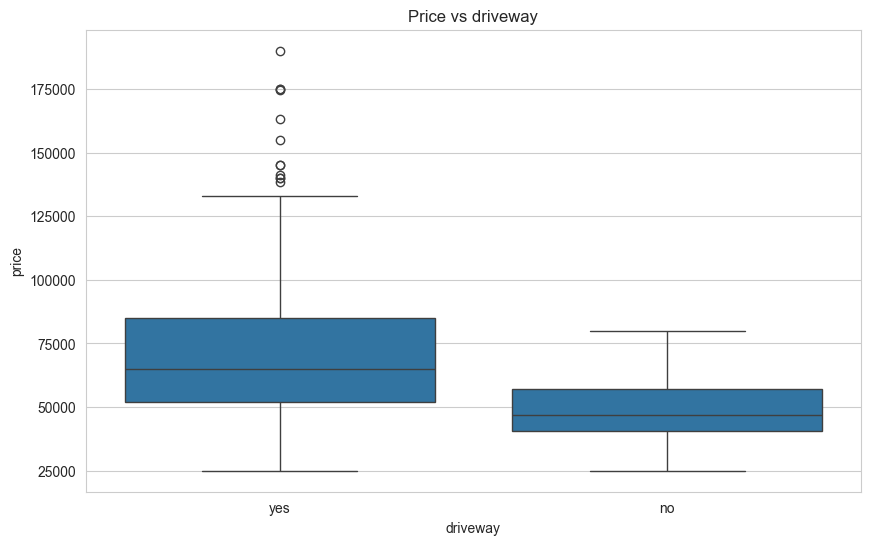

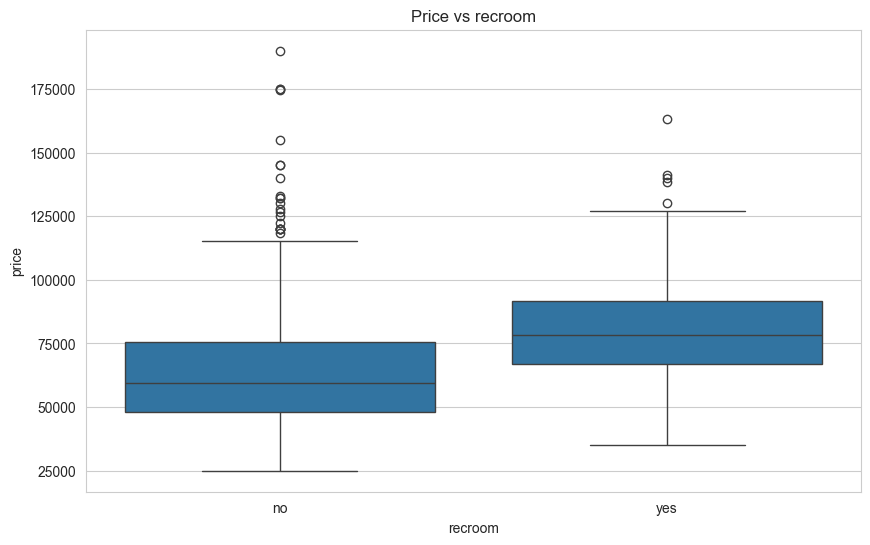

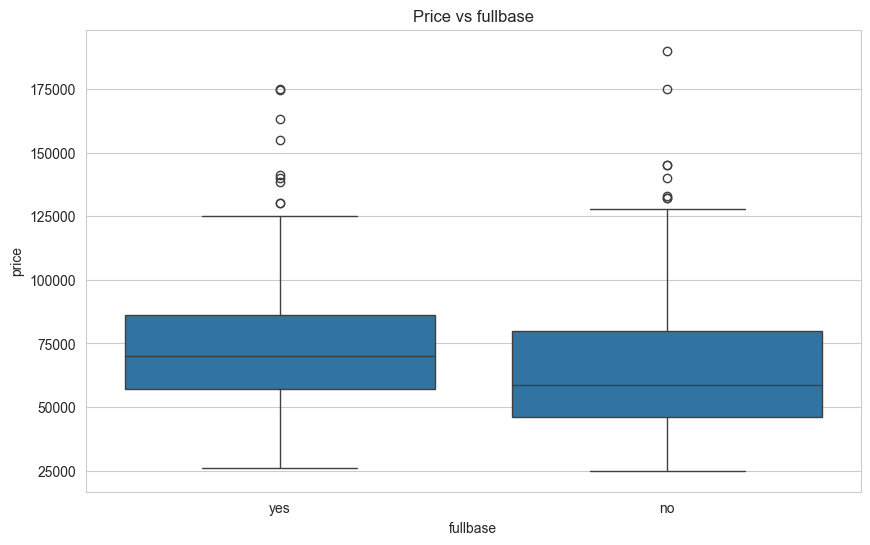

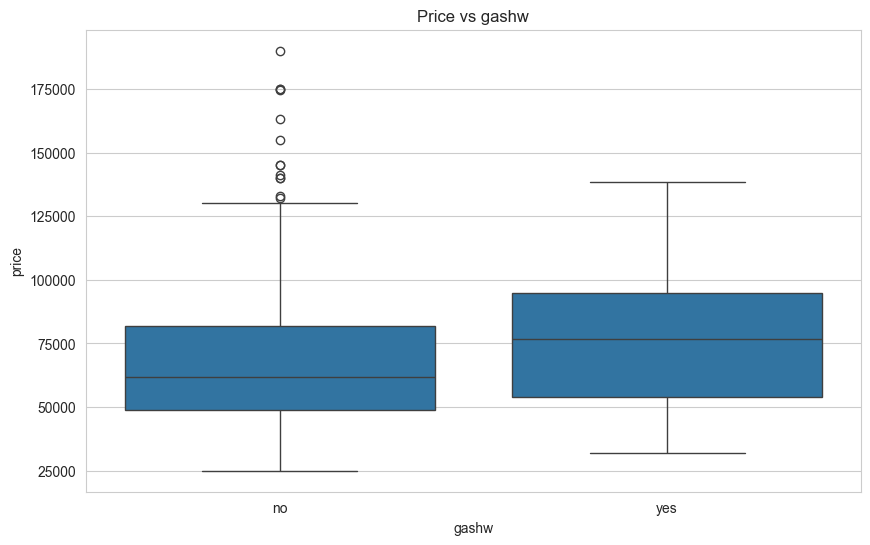

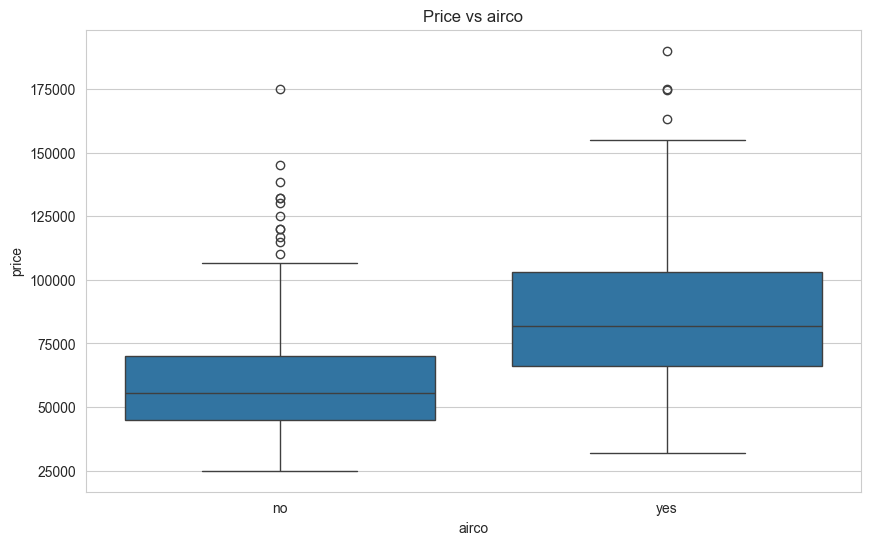

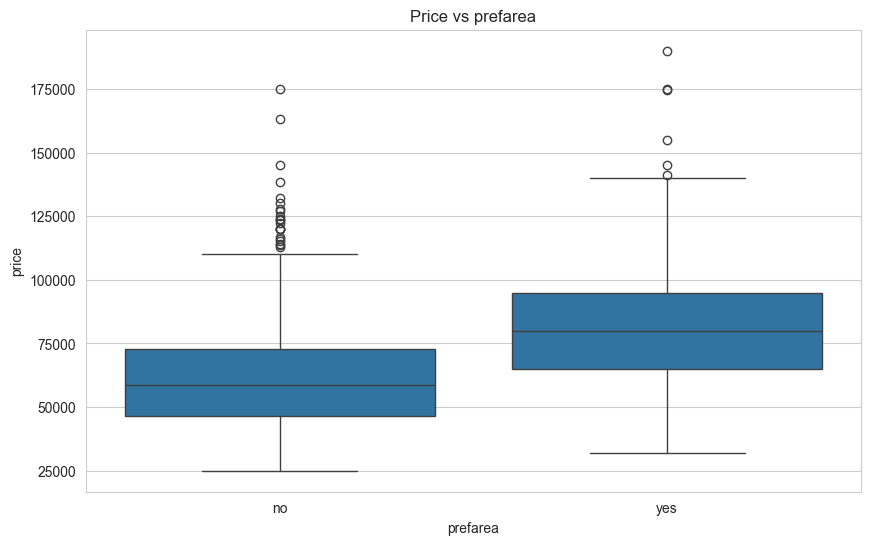

In [16]:
cols = ["driveway", "recroom", "fullbase", "gashw", "airco", "prefarea"]

for col in cols:
    sns.boxplot(x=col, y="price", data=df)
    plt.title(f"Price vs {col}")
    plt.show()

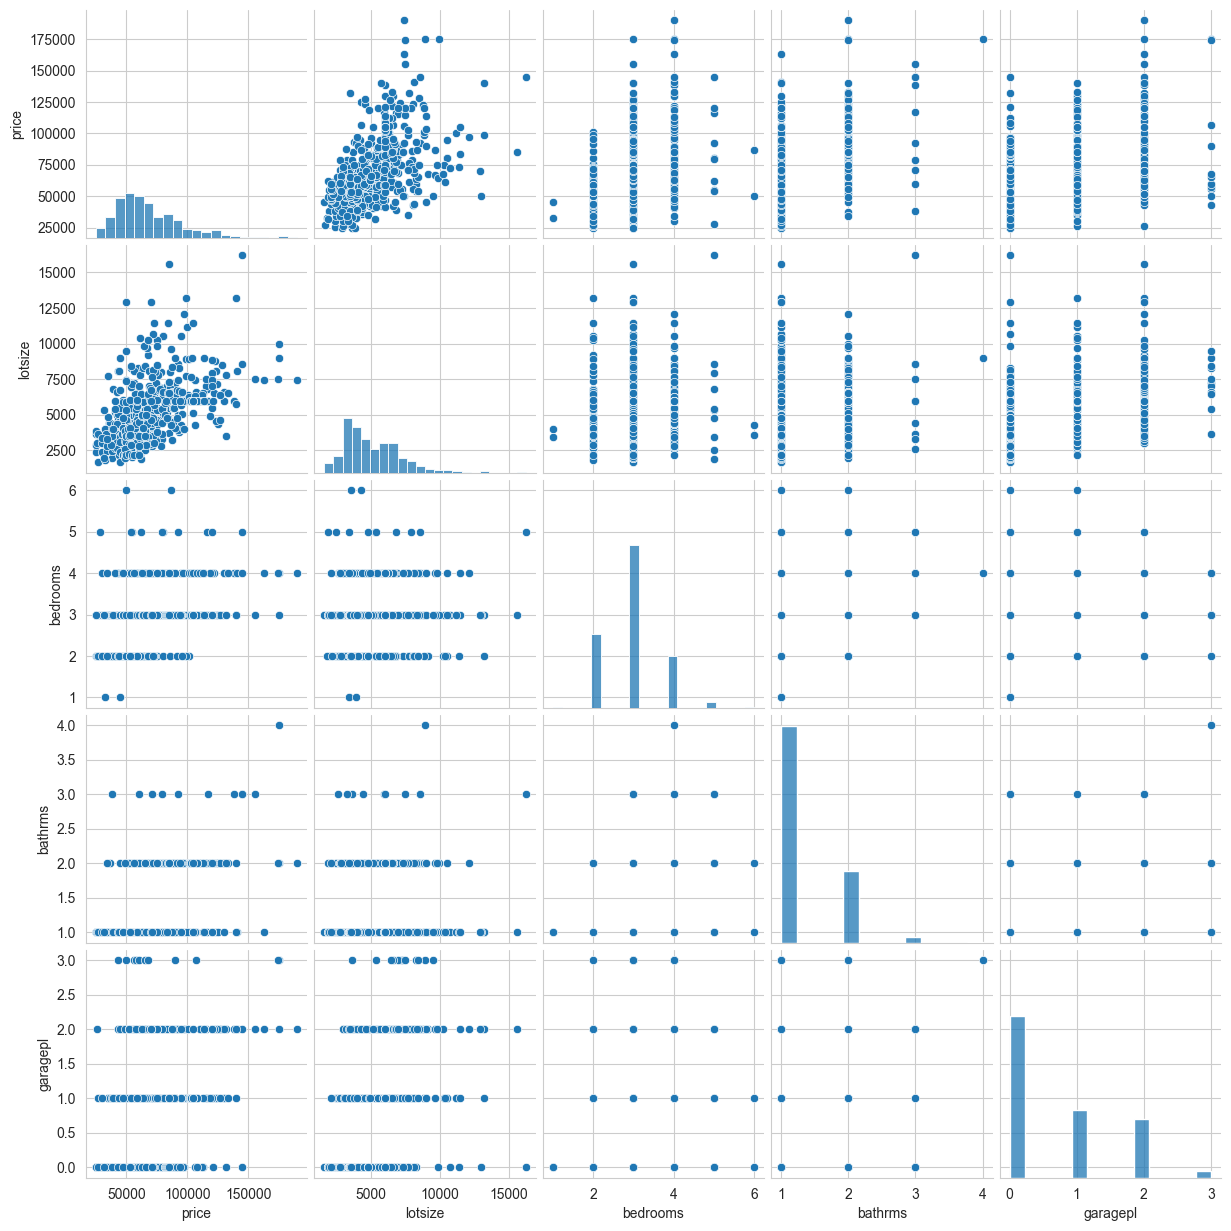

In [17]:
sns.pairplot(df[["price", "lotsize", "bedrooms", "bathrms", "garagepl"]])
plt.show()

In [18]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
df = pd.read_csv("Housing_data.csv")

In [21]:
# convert yes/no → 1/0
df = df.replace({"yes": 1, "no": 0})

In [20]:
df_numeric = df.select_dtypes(include=['number'])

In [22]:
X = df.drop("price", axis=1)
y = df["price"]

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [24]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.6376805805574584
MAE: 11161.192727272726


In [ ]:
sample = np.array([[5850, 3, 1, 2, 1, 1, 0, 1, 0, 0, 1, 0]])

prediction = model.predict(sample)

print("Predicted House Price:", prediction[0])

Predicted House Price: 52257.675


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:

df.columns



Index(['Unnamed: 0', 'price', 'lotsize', 'bedrooms', 'bathrms', 'stories',
       'driveway', 'recroom', 'fullbase', 'gashw', 'airco', 'garagepl',
       'prefarea'],
      dtype='str')

In [ ]:
df.price_per_sqrt=df.price/(df.sqft_living + df.sqft_lot)

AttributeError: 'DataFrame' object has no attribute 'sqft_living'

In [25]:
df.price<50000

0       True
1       True
2       True
3      False
4      False
       ...  
541    False
542    False
543    False
544    False
545    False
Name: price, Length: 546, dtype: bool

In [26]:
df [df.price<5000]

,Unnamed: 0,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea


In [27]:
df[df.price<50000].iloc[:,2:5]

,lotsize,bedrooms,bathrms
0,5850,3,1
1,4000,2,1
2,3060,3,1
11,3000,2,1
12,1700,3,1
...,...,...,...
464,2145,3,1
486,8050,2,1
487,8100,2,1
488,5880,3,1


In [28]:
df[df.price<50000][["bathrms","lotsize"]]

,bathrms,lotsize
0,1,5850
1,1,4000
2,1,3060
11,1,3000
12,1,1700
...,...,...
464,1,2145
486,1,8050
487,1,8100
488,1,5880


In [29]:
(df.price<5000) & (df.lotsize>=10000)

0      False
1      False
2      False
3      False
4      False
       ...  
541    False
542    False
543    False
544    False
545    False
Length: 546, dtype: bool

In [30]:
df[(df.price<=50000) & (df.lotsize>=1000)].price

0      42000.0
1      38500.0
2      49500.0
11     30500.0
12     27000.0
        ...   
487    44100.0
488    47000.0
489    50000.0
490    50000.0
511    47500.0
Name: price, Length: 158, dtype: float64

In [31]:
df.price.nunique()

219

In [32]:
df.price.unique()

array([ 42000.,  38500.,  49500.,  60500.,  61000.,  66000.,  69000.,
        83800.,  88500.,  90000.,  30500.,  27000.,  36000.,  37000.,
        37900.,  40500.,  40750.,  45000.,  48500.,  65900.,  38000.,
        42300.,  43500.,  44000.,  44500.,  44900.,  48000.,  49000.,
        51500.,  61700.,  67000.,  82000.,  54500.,  66500.,  70000.,
        92000.,  41000.,  43000.,  54800.,  55000.,  57000.,  68000.,
        95000.,  25000.,  25245.,  56000.,  35500.,  30000.,  52000.,
        54000.,  60000.,  47000.,  51000.,  32500.,  34000.,  35000.,
        63900.,  50000.,  55500.,  78000.,  58000., 163000., 128000.,
       123500.,  39000.,  53900.,  59900.,  79000., 125000., 132000.,
        58500.,  73000.,  63500.,  46500.,  75000.,  85000.,  93000.,
        94500., 106500., 116000.,  61500.,  80000.,  59500., 117000.,
       122500., 127000.,  49900.,  50500.,  65000.,  46000.,  26500.,
        40000.,  57250.,  62000.,  63000., 130000.,  52900.,  73500.,
        52500.,  320

In [33]:
df['price'].value_counts(dropna=False)



price
60000.0     17
50000.0     17
70000.0     12
45000.0      9
52000.0      9
            ..
107500.0     1
113750.0     1
82500.0      1
91500.0      1
94000.0      1
Name: count, Length: 219, dtype: int64

In [34]:
df.duplicated(keep='last')

0      False
1      False
2      False
3      False
4      False
       ...  
541    False
542    False
543    False
544    False
545    False
Length: 546, dtype: bool

In [35]:
df.drop_duplicates(subset=['bathrms'])


,Unnamed: 0,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,1,42000.0,5850,3,1,2,1,0,1,0,0,1,0
6,7,66000.0,3880,3,2,2,1,0,1,0,0,2,0
43,44,92000.0,8580,5,3,2,1,0,0,0,0,2,0
331,332,175000.0,8960,4,4,4,1,0,0,0,1,3,0


In [36]:
df=pd.read_csv('Housing_Data.csv')

In [37]:
df.price.apply(lambda n: float.is_integer(n**0.5))

0      False
1      False
2      False
3      False
4      False
       ...  
541    False
542    False
543    False
544    False
545    False
Name: price, Length: 546, dtype: bool

In [38]:
df=pd.read_csv("spotify_global_2019_most_streamed_tracks_audio_features.csv")

In [39]:
df

,Country,Rank,Track_id,Streams,Track Name,Artist,URL,acousticness,danceability,energy,...,valence,tempo,time_signature,duration_ms,key,mode,Artist_id,Artist_popularity,Artist_follower,Artist_img
0,global,1.0,25sgk305KZfyuqVBQIahim,1166185736,Sweet but Psycho,Ava Max,https://open.spotify.com/track/25sgk305KZfyuqV...,0.0691,0.719,0.704,...,0.628,133.002,4,187436,1,1,4npEfmQ6YuiwW1GpUmaq3F,87,1025358,https://i.scdn.co/image/4b914c6470c8458674538a...
1,global,2.0,2Fxmhks0bxGSBdJ92vM42m,1052358787,bad guy,Billie Eilish,https://open.spotify.com/track/2Fxmhks0bxGSBdJ...,0.3280,0.701,0.425,...,0.562,135.128,4,194088,7,1,6qqNVTkY8uBg9cP3Jd7DAH,98,18867904,https://i.scdn.co/image/2622edec99d68d1d141886...
2,global,3.0,6ocbgoVGwYJhOv1GgI9NsF,789094044,7 rings,Ariana Grande,https://open.spotify.com/track/6ocbgoVGwYJhOv1...,0.5920,0.778,0.317,...,0.327,140.048,4,178627,1,0,66CXWjxzNUsdJxJ2JdwvnR,97,40958727,https://i.scdn.co/image/b1dfbe843b0b9f54ab2e58...
3,global,4.0,1rgnBhdG2JDFTbYkYRZAku,764208309,Dance Monkey,Tones and I,https://open.spotify.com/track/1rgnBhdG2JDFTbY...,0.6880,0.825,0.593,...,0.540,98.078,4,209755,6,0,2NjfBq1NflQcKSeiDooVjY,92,484241,https://i.scdn.co/image/c128f5ef4d210a67610acd...
4,global,5.0,6v3KW9xbzN5yKLt9YKDYA2,763064359,Señorita,Shawn Mendes,https://open.spotify.com/track/6v3KW9xbzN5yKLt...,0.0392,0.759,0.548,...,0.749,116.967,4,190800,9,0,7n2wHs1TKAczGzO7Dd2rGr,94,23152263,https://i.scdn.co/image/6bd59cfbd3e1e6394af710...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1712,global,1713.0,27SdWb2rFzO6GWiYDBTD9j,554971,Cheap Thrills,Sia,https://open.spotify.com/track/27SdWb2rFzO6GWi...,0.0472,0.628,0.698,...,0.732,89.976,4,211667,6,0,5WUlDfRSoLAfcVSX1WnrxN,90,15317280,https://i.scdn.co/image/652b6bb0dfaf8aa444f441...
1713,global,1714.0,0kLA41xkWzzYzMIEGFuDkP,544655,HaifischNikez Allstars,LX,https://open.spotify.com/track/0kLA41xkWzzYzMI...,0.1620,0.764,0.744,...,0.507,87.538,4,182925,11,0,10XY9PZCJKzUFzZOdtlQLU,71,64625,https://i.scdn.co/image/60d0c075d6de8417a0c44d...
1714,global,1715.0,79hJaqmVdohltPBNN6BULM,536886,"Stayin' Alive - From ""Saturday Night Fever"" So...",Bee Gees,https://open.spotify.com/track/79hJaqmVdohltPB...,0.0700,0.708,0.567,...,0.955,103.606,4,281667,10,0,1LZEQNv7sE11VDY3SdxQeN,79,2834719,https://i.scdn.co/image/1d5a05673975ba0c378cd2...
1715,global,1716.0,7rLegaz7zKB6EtDNzcslKE,536447,Medley da Gaiola - Dennis DJ Remix,MC Kevin o Chris,https://open.spotify.com/track/7rLegaz7zKB6EtD...,0.7110,0.896,0.756,...,0.686,140.076,4,240000,4,0,2UMj7NCbuqy1yUZmiSYGjJ,84,1139072,https://i.scdn.co/image/984dfbcdcf7880b022478b...


In [40]:
df.Artist

0                  Ava Max
1            Billie Eilish
2            Ariana Grande
3              Tones and I
4             Shawn Mendes
               ...        
1712                   Sia
1713                    LX
1714              Bee Gees
1715      MC Kevin o Chris
1716    Henrique & Juliano
Name: Artist, Length: 1717, dtype: str

In [41]:
df.Artist.unique

<bound method Series.unique of 0                  Ava Max
1            Billie Eilish
2            Ariana Grande
3              Tones and I
4             Shawn Mendes
               ...        
1712                   Sia
1713                    LX
1714              Bee Gees
1715      MC Kevin o Chris
1716    Henrique & Juliano
Name: Artist, Length: 1717, dtype: str>

In [42]:
df.Artist.nunique

<bound method IndexOpsMixin.nunique of 0                  Ava Max
1            Billie Eilish
2            Ariana Grande
3              Tones and I
4             Shawn Mendes
               ...        
1712                   Sia
1713                    LX
1714              Bee Gees
1715      MC Kevin o Chris
1716    Henrique & Juliano
Name: Artist, Length: 1717, dtype: str>

In [43]:
'BTS' in df.Artist.value_counts()

True

In [44]:
df.Artist.value_counts()['BTS']

np.int64(11)

In [45]:
"jonny sins" in df.Artist.value_counts()

False

In [46]:
'Drake' in df.Artist.value_counts()


True

In [47]:
'BTS' in df.Artist.value_counts()

True

In [48]:
'Marshmello' in df.Artist.value_counts()

True

In [49]:
df[df.Artist_popularity>99]

,Country,Rank,Track_id,Streams,Track Name,Artist,URL,acousticness,danceability,energy,...,valence,tempo,time_signature,duration_ms,key,mode,Artist_id,Artist_popularity,Artist_follower,Artist_img
9,global,10.0,6MWtB6iiXyIwun0YzU6DFP,615519053,Wow.,Post Malone,https://open.spotify.com/track/6MWtB6iiXyIwun0...,0.1630,0.833,0.539,...,0.385,99.947,4,149520,11,0,246dkjvS1zLTtiykXe5h60,100,21335421,https://i.scdn.co/image/93fec27f9aac86526b9010...
13,global,14.0,6vBdBCoOhKHiYDDOcorfNo,501130662,Goodbyes (Feat. Young Thug),Post Malone,https://open.spotify.com/track/6vBdBCoOhKHiYDD...,0.4470,0.580,0.653,...,0.175,150.231,4,174960,5,1,246dkjvS1zLTtiykXe5h60,100,21335421,https://i.scdn.co/image/93fec27f9aac86526b9010...
25,global,26.0,21jGcNKet2qwijlDFuPiPb,428712946,Circles,Post Malone,https://open.spotify.com/track/21jGcNKet2qwijl...,0.1920,0.695,0.762,...,0.553,120.042,4,215280,0,1,246dkjvS1zLTtiykXe5h60,100,21335421,https://i.scdn.co/image/93fec27f9aac86526b9010...
31,global,32.0,7dt6x5M1jzdTEt8oCbisTK,405953336,Better Now,Post Malone,https://open.spotify.com/track/7dt6x5M1jzdTEt8...,0.3310,0.680,0.578,...,0.341,145.038,4,231267,10,1,246dkjvS1zLTtiykXe5h60,100,21335421,https://i.scdn.co/image/93fec27f9aac86526b9010...
33,global,34.0,0e7ipj03S05BNilyu5bRzt,395449434,rockstar (feat. 21 Savage),Post Malone,https://open.spotify.com/track/0e7ipj03S05BNil...,0.1240,0.585,0.520,...,0.129,159.801,4,218147,5,0,246dkjvS1zLTtiykXe5h60,100,21335421,https://i.scdn.co/image/93fec27f9aac86526b9010...
112,global,113.0,0RiRZpuVRbi7oqRdSMwhQY,209280692,Sunflower - Spider-Man: Into the Spider-Verse,Post Malone,https://open.spotify.com/track/0RiRZpuVRbi7oqR...,0.5330,0.755,0.522,...,0.925,89.960,4,157560,2,1,246dkjvS1zLTtiykXe5h60,100,21335421,https://i.scdn.co/image/93fec27f9aac86526b9010...
125,global,126.0,3swc6WTsr7rl9DqQKQA55C,195603663,Psycho (feat. Ty Dolla $ign),Post Malone,https://open.spotify.com/track/3swc6WTsr7rl9Dq...,0.5460,0.750,0.560,...,0.459,140.060,4,221440,8,1,246dkjvS1zLTtiykXe5h60,100,21335421,https://i.scdn.co/image/93fec27f9aac86526b9010...
173,global,174.0,7CZyCXKG6d5ALeq41sLzbw,153232549,Take What You Want (feat. Ozzy Osbourne & Trav...,Post Malone,https://open.spotify.com/track/7CZyCXKG6d5ALeq...,0.0906,0.499,0.800,...,0.272,139.919,4,229573,1,0,246dkjvS1zLTtiykXe5h60,100,21335421,https://i.scdn.co/image/93fec27f9aac86526b9010...
191,global,192.0,3a1lNhkSLSkpJE4MSHpDu9,142006864,Congratulations,Post Malone,https://open.spotify.com/track/3a1lNhkSLSkpJE4...,0.2150,0.630,0.804,...,0.492,123.146,4,220293,6,1,246dkjvS1zLTtiykXe5h60,100,21335421,https://i.scdn.co/image/93fec27f9aac86526b9010...
227,global,228.0,05mDaV9Vb3wrzjF6OPZnhq,118147209,Saint-Tropez,Post Malone,https://open.spotify.com/track/05mDaV9Vb3wrzjF...,0.0545,0.617,0.684,...,0.295,132.113,4,150867,0,1,246dkjvS1zLTtiykXe5h60,100,21335421,https://i.scdn.co/image/93fec27f9aac86526b9010...


In [50]:
import pandas as pd


In [51]:
pd.NA

<NA>

In [52]:
type(pd.NA)

pandas.api.typing.NAType

In [53]:
type(pd.NaT)

pandas.api.typing.NaTType

In [54]:
df[df["Artist"]==pd.NaT].isna

<bound method DataFrame.isna of Empty DataFrame
Columns: [Country, Rank, Track_id, Streams, Track Name, Artist, URL, acousticness, danceability, energy, instrumentalness, liveness, loudness, speechiness, valence, tempo, time_signature, duration_ms, key, mode, Artist_id, Artist_popularity, Artist_follower, Artist_img]
Index: []

[0 rows x 24 columns]>

In [55]:
df.Artist.isna().sum()/len(df)

np.float64(0.0)

In [56]:
pop_song=df[df.Artist_popularity>90]

In [57]:
rank=pop_song['Artist'].value_counts()

In [58]:
rank

Artist
Post Malone      45
Juice WRLD       31
Ariana Grande    28
Billie Eilish    27
Taylor Swift     27
                 ..
Eminem            1
Nicki Minaj       1
Rihanna           1
Bass Santana      1
Bruno Mars        1
Name: count, Length: 62, dtype: int64

In [ ]:
type(rank)

pandas.Series

In [ ]:
pop_song['Artist'].unique()

<StringArray>
[             'Billie Eilish',              'Ariana Grande',
                'Tones and I',               'Shawn Mendes',
               'Daddy Yankee',              'Lewis Capaldi',
                'Post Malone',                     'Halsey',
                  'Sam Smith',                 'Ed Sheeran',
                   'Anuel AA',                  'Bad Bunny',
                    'J. Cole',               'Travis Scott',
                 'Juice WRLD',                   'Maroon 5',
                     'Khalid',                       'Sech',
                      'Drake',               'XXXTENTACION',
                       'Lauv',                   'J Balvin',
     'A Boogie Wit da Hoodie',            'Imagine Dragons',
                      'Queen',                      'Ozuna',
                  'Nicky Jam',                     'Maluma',
                'Chris Brown',                   'Lil Baby',
                     'DaBaby',                        'BTS',
          

In [ ]:
'BTS' in rank

True

In [59]:
bts=pop_song[pop_song['Artist']=='BTS']

In [60]:
bts.shape

(11, 24)

In [ ]:
bts

,Country,Rank,Track_id,Streams,Track Name,Artist,URL,acousticness,danceability,energy,...,valence,tempo,time_signature,duration_ms,key,mode,Artist_id,Artist_popularity,Artist_follower,Artist_img
86,global,87.0,5KawlOMHjWeUjQtnuRs22c,261504425,Boy With Luv (feat. Halsey),BTS,https://open.spotify.com/track/5KawlOMHjWeUjQt...,0.0923,0.645,0.862,...,0.798,119.991,4,229773,11,0,3Nrfpe0tUJi4K4DXYWgMUX,93,15652748,https://i.scdn.co/image/0c9057cb30520f9f883a22...
464,global,465.0,314ZkcV7oLWG8yWE7LABvH,42873724,Make It Right (feat. Lauv),BTS,https://open.spotify.com/track/314ZkcV7oLWG8yW...,0.0304,0.584,0.685,...,0.345,97.551,4,226321,7,1,3Nrfpe0tUJi4K4DXYWgMUX,93,15652748,https://i.scdn.co/image/0c9057cb30520f9f883a22...
676,global,677.0,5hnbE5BF2e8BCk9OMR1UVC,18801822,Mikrokosmos,BTS,https://open.spotify.com/track/5hnbE5BF2e8BCk9...,0.1250,0.580,0.858,...,0.475,174.039,3,224225,8,1,3Nrfpe0tUJi4K4DXYWgMUX,93,15652748,https://i.scdn.co/image/0c9057cb30520f9f883a22...
678,global,679.0,4c1WgUnHXq2LEncGHKgj1I,18648089,Dream Glow (BTS World Original Soundtrack) - P...,BTS,https://open.spotify.com/track/4c1WgUnHXq2LEnc...,0.0967,0.735,0.740,...,0.541,141.948,4,187458,0,0,3Nrfpe0tUJi4K4DXYWgMUX,93,15652748,https://i.scdn.co/image/0c9057cb30520f9f883a22...
681,global,682.0,6KUE0HSSudAp9AOycaF6SH,18423901,Make It Right,BTS,https://open.spotify.com/track/6KUE0HSSudAp9AO...,0.0104,0.638,0.703,...,0.261,105.766,4,226321,7,1,3Nrfpe0tUJi4K4DXYWgMUX,93,15652748,https://i.scdn.co/image/0c9057cb30520f9f883a22...
710,global,711.0,7lthOBXNue2IvedLRfkod8,16442038,HOME,BTS,https://open.spotify.com/track/7lthOBXNue2Ived...,0.0142,0.633,0.799,...,0.535,142.991,4,234178,7,0,3Nrfpe0tUJi4K4DXYWgMUX,93,15652748,https://i.scdn.co/image/0c9057cb30520f9f883a22...
725,global,726.0,6JdS5rJvJaRA7B1tcm7kxZ,15134946,Dionysus,BTS,https://open.spotify.com/track/6JdS5rJvJaRA7B1...,0.0400,0.502,0.910,...,0.588,176.084,4,249215,7,1,3Nrfpe0tUJi4K4DXYWgMUX,93,15652748,https://i.scdn.co/image/0c9057cb30520f9f883a22...
778,global,779.0,0eeeyCAGnGZInPtpkdYiPa,12992565,Jamais Vu,BTS,https://open.spotify.com/track/0eeeyCAGnGZInPt...,0.2260,0.608,0.470,...,0.241,81.000,4,227275,8,1,3Nrfpe0tUJi4K4DXYWgMUX,93,15652748,https://i.scdn.co/image/0c9057cb30520f9f883a22...
883,global,884.0,2isSdmQfVv32j2haL6hk9x,8775556,Intro : Persona,BTS,https://open.spotify.com/track/2isSdmQfVv32j2h...,0.0278,0.469,0.870,...,0.652,86.622,4,171023,9,0,3Nrfpe0tUJi4K4DXYWgMUX,93,15652748,https://i.scdn.co/image/0c9057cb30520f9f883a22...
1057,global,1058.0,5XkyZyKMdFungjDb9cUKc3,4383131,A Brand New Day (BTS World Original Soundtrack...,BTS,https://open.spotify.com/track/5XkyZyKMdFungjD...,0.3390,0.804,0.498,...,0.704,105.008,4,205020,8,0,3Nrfpe0tUJi4K4DXYWgMUX,93,15652748,https://i.scdn.co/image/0c9057cb30520f9f883a22...


In [ ]:
play_list=pop_song[pop_song['Artist']=='Post Malone']

In [ ]:
Malone=play_list.reset_index(drop=True,inplace=False)

In [ ]:
Malone

,Country,Rank,Track_id,Streams,Track Name,Artist,URL,acousticness,danceability,energy,...,valence,tempo,time_signature,duration_ms,key,mode,Artist_id,Artist_popularity,Artist_follower,Artist_img
0,global,10.0,6MWtB6iiXyIwun0YzU6DFP,615519053,Wow.,Post Malone,https://open.spotify.com/track/6MWtB6iiXyIwun0...,0.1630,0.833,0.539,...,0.385,99.947,4,149520,11,0,246dkjvS1zLTtiykXe5h60,100,21335421,https://i.scdn.co/image/93fec27f9aac86526b9010...
1,global,14.0,6vBdBCoOhKHiYDDOcorfNo,501130662,Goodbyes (Feat. Young Thug),Post Malone,https://open.spotify.com/track/6vBdBCoOhKHiYDD...,0.4470,0.580,0.653,...,0.175,150.231,4,174960,5,1,246dkjvS1zLTtiykXe5h60,100,21335421,https://i.scdn.co/image/93fec27f9aac86526b9010...
2,global,26.0,21jGcNKet2qwijlDFuPiPb,428712946,Circles,Post Malone,https://open.spotify.com/track/21jGcNKet2qwijl...,0.1920,0.695,0.762,...,0.553,120.042,4,215280,0,1,246dkjvS1zLTtiykXe5h60,100,21335421,https://i.scdn.co/image/93fec27f9aac86526b9010...
3,global,32.0,7dt6x5M1jzdTEt8oCbisTK,405953336,Better Now,Post Malone,https://open.spotify.com/track/7dt6x5M1jzdTEt8...,0.3310,0.680,0.578,...,0.341,145.038,4,231267,10,1,246dkjvS1zLTtiykXe5h60,100,21335421,https://i.scdn.co/image/93fec27f9aac86526b9010...
4,global,34.0,0e7ipj03S05BNilyu5bRzt,395449434,rockstar (feat. 21 Savage),Post Malone,https://open.spotify.com/track/0e7ipj03S05BNil...,0.1240,0.585,0.520,...,0.129,159.801,4,218147,5,0,246dkjvS1zLTtiykXe5h60,100,21335421,https://i.scdn.co/image/93fec27f9aac86526b9010...
5,global,113.0,0RiRZpuVRbi7oqRdSMwhQY,209280692,Sunflower - Spider-Man: Into the Spider-Verse,Post Malone,https://open.spotify.com/track/0RiRZpuVRbi7oqR...,0.5330,0.755,0.522,...,0.925,89.960,4,157560,2,1,246dkjvS1zLTtiykXe5h60,100,21335421,https://i.scdn.co/image/93fec27f9aac86526b9010...
6,global,126.0,3swc6WTsr7rl9DqQKQA55C,195603663,Psycho (feat. Ty Dolla $ign),Post Malone,https://open.spotify.com/track/3swc6WTsr7rl9Dq...,0.5460,0.750,0.560,...,0.459,140.060,4,221440,8,1,246dkjvS1zLTtiykXe5h60,100,21335421,https://i.scdn.co/image/93fec27f9aac86526b9010...
7,global,174.0,7CZyCXKG6d5ALeq41sLzbw,153232549,Take What You Want (feat. Ozzy Osbourne & Trav...,Post Malone,https://open.spotify.com/track/7CZyCXKG6d5ALeq...,0.0906,0.499,0.800,...,0.272,139.919,4,229573,1,0,246dkjvS1zLTtiykXe5h60,100,21335421,https://i.scdn.co/image/93fec27f9aac86526b9010...
8,global,192.0,3a1lNhkSLSkpJE4MSHpDu9,142006864,Congratulations,Post Malone,https://open.spotify.com/track/3a1lNhkSLSkpJE4...,0.2150,0.630,0.804,...,0.492,123.146,4,220293,6,1,246dkjvS1zLTtiykXe5h60,100,21335421,https://i.scdn.co/image/93fec27f9aac86526b9010...
9,global,228.0,05mDaV9Vb3wrzjF6OPZnhq,118147209,Saint-Tropez,Post Malone,https://open.spotify.com/track/05mDaV9Vb3wrzjF...,0.0545,0.617,0.684,...,0.295,132.113,4,150867,0,1,246dkjvS1zLTtiykXe5h60,100,21335421,https://i.scdn.co/image/93fec27f9aac86526b9010...


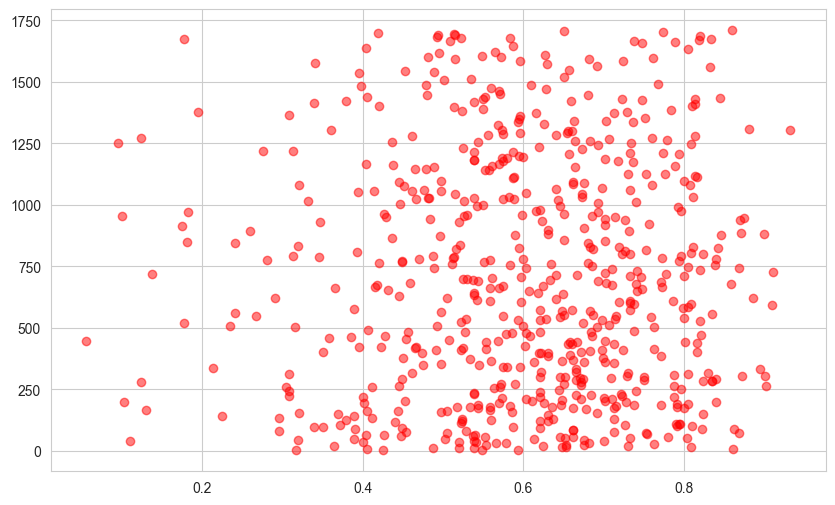

In [ ]:
x=pop_song['energy']
y=pop_song['Rank']
plt.scatter(x,y,color='red',alpha=0.5)
plt.show()

In [ ]:
cor=pop_song.corr(method='pearson',numeric_only=True)

In [ ]:
cor

,Rank,Streams,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,tempo,time_signature,duration_ms,key,mode,Artist_popularity,Artist_follower
Rank,1.000000,-0.667177,-0.032689,-0.014811,0.015078,-0.010819,0.012798,0.000376,0.065916,-0.066742,0.055495,-0.033160,-0.067052,0.033910,0.003724,-0.125771,-0.153893
Streams,-0.667177,1.000000,0.064805,0.084925,-0.061912,0.006551,-0.057213,-0.028443,0.016573,0.036415,-0.034935,0.050560,0.075025,0.016519,-0.042764,0.076414,0.107483
acousticness,-0.032689,0.064805,1.000000,-0.267700,-0.596283,0.171176,-0.069286,-0.468497,-0.096948,-0.158757,-0.200414,-0.153084,0.023573,0.001182,0.043079,0.082446,0.058096
danceability,-0.014811,0.084925,-0.267700,1.000000,0.116359,-0.060219,-0.082180,0.168947,0.261145,0.343914,0.040506,0.216780,-0.189032,0.064711,-0.089370,-0.084745,-0.118009
energy,0.015078,-0.061912,-0.596283,0.116359,1.000000,-0.131759,0.064614,0.748667,0.033865,0.431950,0.245615,0.203579,0.000849,0.048853,-0.062312,0.019909,0.023370
instrumentalness,-0.010819,0.006551,0.171176,-0.060219,-0.131759,1.000000,-0.043743,-0.236599,0.018153,-0.100112,0.046055,-0.069684,0.007569,-0.073847,-0.091529,0.080346,-0.031215
liveness,0.012798,-0.057213,-0.069286,-0.082180,0.064614,-0.043743,1.000000,-0.029890,-0.017274,-0.009851,-0.062365,-0.005435,-0.032725,0.041308,-0.062834,-0.012349,0.017883
loudness,0.000376,-0.028443,-0.468497,0.168947,0.748667,-0.236599,-0.029890,1.000000,-0.060650,0.355557,0.193311,0.179209,-0.050713,0.020831,-0.000384,0.031803,-0.011165
speechiness,0.065916,0.016573,-0.096948,0.261145,0.033865,0.018153,-0.017274,-0.060650,1.000000,0.137190,0.160343,0.101842,-0.086407,0.055606,-0.091669,0.004194,-0.046792
valence,-0.066742,0.036415,-0.158757,0.343914,0.431950,-0.100112,-0.009851,0.355557,0.137190,1.000000,0.043322,0.130938,-0.079664,0.107105,-0.044804,-0.073404,0.001671


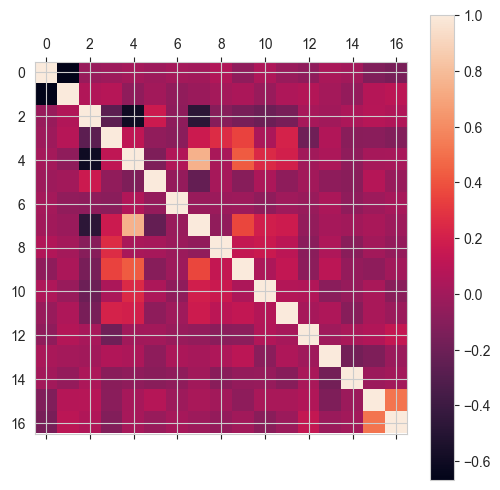

In [ ]:
plt.matshow(cor)
plt.colorbar()
plt.show()

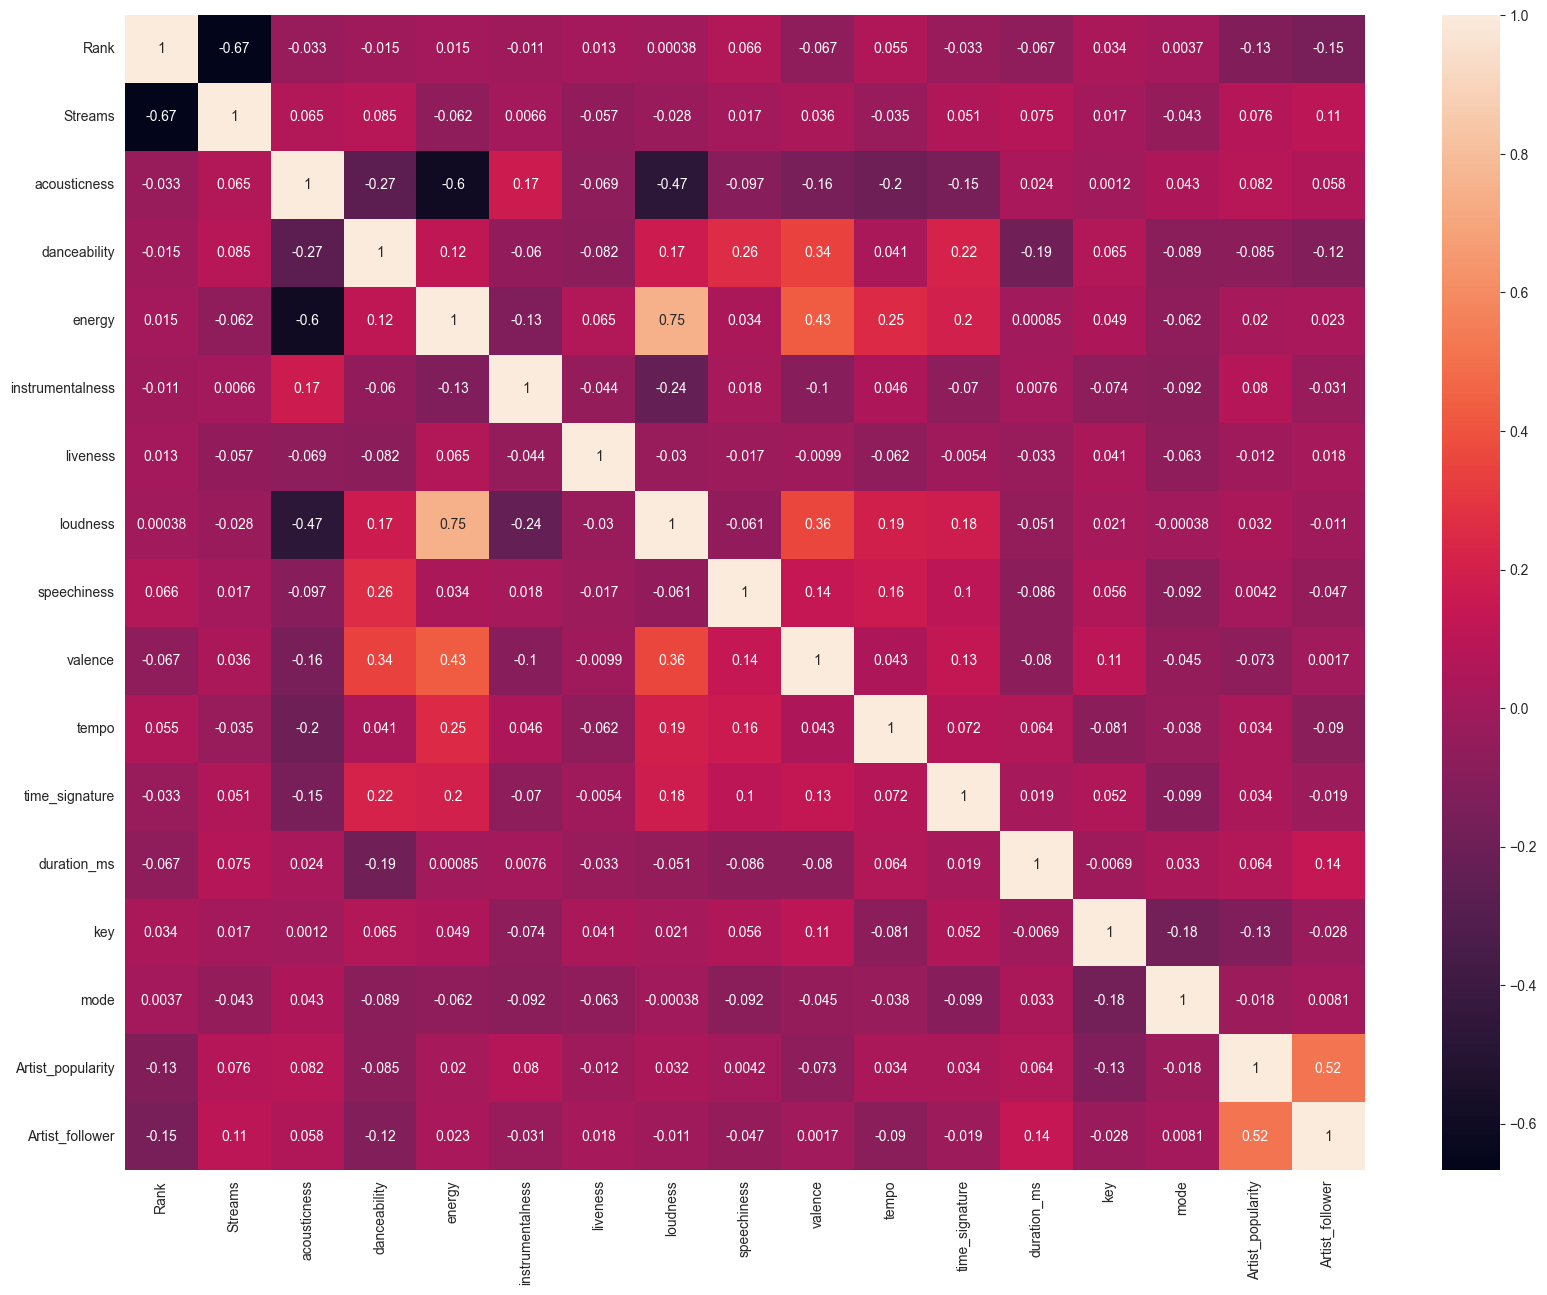

In [ ]:
plt.figure(figsize=(20,15))
sns.heatmap(cor,annot=True)
plt.show()

In [ ]:
df.info

<bound method DataFrame.info of      Country    Rank                Track_id     Streams  \
0     global     1.0  25sgk305KZfyuqVBQIahim  1166185736   
1     global     2.0  2Fxmhks0bxGSBdJ92vM42m  1052358787   
2     global     3.0  6ocbgoVGwYJhOv1GgI9NsF   789094044   
3     global     4.0  1rgnBhdG2JDFTbYkYRZAku   764208309   
4     global     5.0  6v3KW9xbzN5yKLt9YKDYA2   763064359   
...      ...     ...                     ...         ...   
1712  global  1713.0  27SdWb2rFzO6GWiYDBTD9j      554971   
1713  global  1714.0  0kLA41xkWzzYzMIEGFuDkP      544655   
1714  global  1715.0  79hJaqmVdohltPBNN6BULM      536886   
1715  global  1716.0  7rLegaz7zKB6EtDNzcslKE      536447   
1716  global  1717.0  0kCqaybZgYcLYxzZymmBoc      524230   

                                             Track Name              Artist  \
0                                      Sweet but Psycho             Ava Max   
1                                               bad guy       Billie Eilish   
2         

In [ ]:
avg_play=df['Streams'].mean(axis=0)

In [ ]:
avg_play

np.float64(51661752.19510774)

In [ ]:
med_play=df['Streams'].median(axis=0)

In [ ]:
med_play


np.float64(9623926.0)

In [ ]:
df['Artist'].head(9)

0          Ava Max
1    Billie Eilish
2    Ariana Grande
3      Tones and I
4     Shawn Mendes
5     Daddy Yankee
6        Lady Gaga
7    Lewis Capaldi
8       Marshmello
Name: Artist, dtype: str

In [ ]:
df.isnull().sum()

Country              0
Rank                 0
Track_id             0
Streams              0
Track Name           0
Artist               0
URL                  0
acousticness         0
danceability         0
energy               0
instrumentalness     0
liveness             0
loudness             0
speechiness          0
valence              0
tempo                0
time_signature       0
duration_ms          0
key                  0
mode                 0
Artist_id            0
Artist_popularity    0
Artist_follower      0
Artist_img           0
dtype: int64

In [ ]:
df=sns.load_dataset('titanic',cache=True)

In [ ]:
df.shape

(891, 15)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [ ]:
df['deck'].value_counts()

deck
C    59
B    47
D    33
E    32
A    15
F    13
G     4
Name: count, dtype: int64

In [ ]:
df['deck'].value_counts(dropna=False)

deck
NaN    688
C       59
B       47
D       33
E       32
A       15
F       13
G        4
Name: count, dtype: int64

In [ ]:
df.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.notnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,True,True,True,True,True,True,True,True,True,True,True,False,True,True,True
1,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True,True,True,False,True,True,True
3,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,True,True,True,True,True,True,True,True,True,True,True,False,True,True,True
887,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
888,True,True,True,False,True,True,True,True,True,True,True,False,True,True,True
889,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


In [ ]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [ ]:
df.isnull().sum().sum()

np.int64(869)

In [ ]:
(len(df)-df.count()).sum()

np.int64(869)

In [ ]:
new_df=df.dropna(axis=1,thresh=500)

In [ ]:
new_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [ ]:
age_df=df.dropna(axis=0,how='any',subset=['age'])

In [ ]:
len(age_df)

714

In [ ]:
no=df.dropna()

In [ ]:
no.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

In [ ]:
df['age'].head(10)


0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
5     NaN
6    54.0
7     2.0
8    27.0
9    14.0
Name: age, dtype: float64

In [ ]:
avg_age=df['age'].mean(axis=0)
avg_age

np.float64(29.69911764705882)

In [ ]:
med_age=df['age'].median(axis=0)
med_age

np.float64(28.0)

In [ ]:
df['age'].fillna(avg_age,inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18276\21705529.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['age'].fillna(avg_age,inplace=True)


0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: age, Length: 891, dtype: float64

In [ ]:
df['age'].head(10)

0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
5     NaN
6    54.0
7     2.0
8    27.0
9    14.0
Name: age, dtype: float64

In [ ]:
df.isnull().sum(0)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18276\1381888268.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  df.isnull().sum(0)


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [ ]:
town_count=df['embark_town'].value_counts(dropna=True)

In [ ]:
town_count

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

In [ ]:
most=town_count.idxmax()

In [ ]:
most

'Southampton'

In [ ]:
df['embark_town'].fillna(most,inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18276\2128170952.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['embark_town'].fillna(most,inplace=True)


0      Southampton
1        Cherbourg
2      Southampton
3      Southampton
4      Southampton
          ...     
886    Southampton
887    Southampton
888    Southampton
889      Cherbourg
890     Queenstown
Name: embark_town, Length: 891, dtype: str

In [ ]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [ ]:
df_01=df['embark_town'].ffill
df_01

<bound method NDFrame.ffill of 0      Southampton
1        Cherbourg
2      Southampton
3      Southampton
4      Southampton
          ...     
886    Southampton
887    Southampton
888    Southampton
889      Cherbourg
890     Queenstown
Name: embark_town, Length: 891, dtype: str>

In [ ]:
student_data=pd.read_csv('student-mat.csv')

In [ ]:
student_data.head()

,school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
0,"GP;""F"";18;""U"";""GT3"";""A"";4;4;""at_home"";""teacher..."
1,"GP;""F"";17;""U"";""GT3"";""T"";1;1;""at_home"";""other"";..."
2,"GP;""F"";15;""U"";""LE3"";""T"";1;1;""at_home"";""other"";..."
3,"GP;""F"";15;""U"";""GT3"";""T"";4;2;""health"";""services..."
4,"GP;""F"";16;""U"";""GT3"";""T"";3;3;""other"";""other"";""h..."


In [ ]:
student_data=pd.read_csv('student-mat.csv',sep=';')

In [ ]:
student_data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
student_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [ ]:
student_data.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [ ]:
student_data.isnull().sum().sum(0)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18276\3202395906.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  student_data.isnull().sum().sum(0)


np.int64(0)

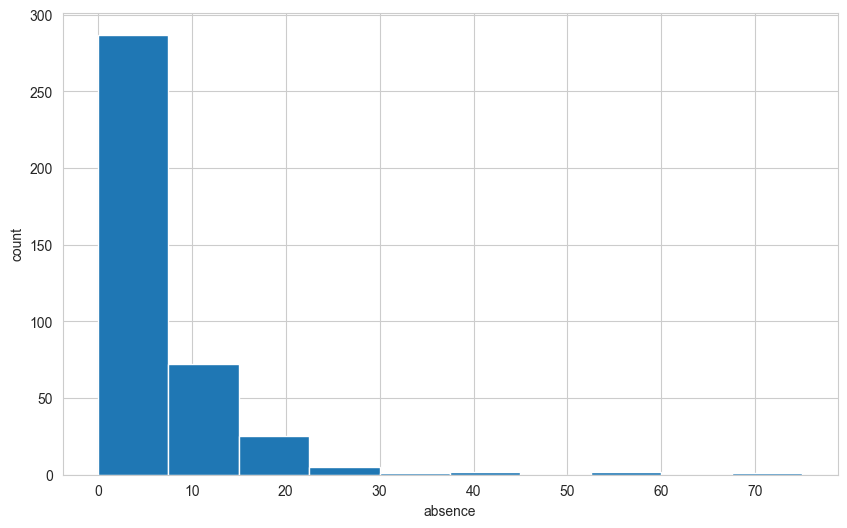

In [ ]:
plt.hist(student_data['absences'])
plt.xlabel('absence')
plt.ylabel('count')
plt.grid=(True)


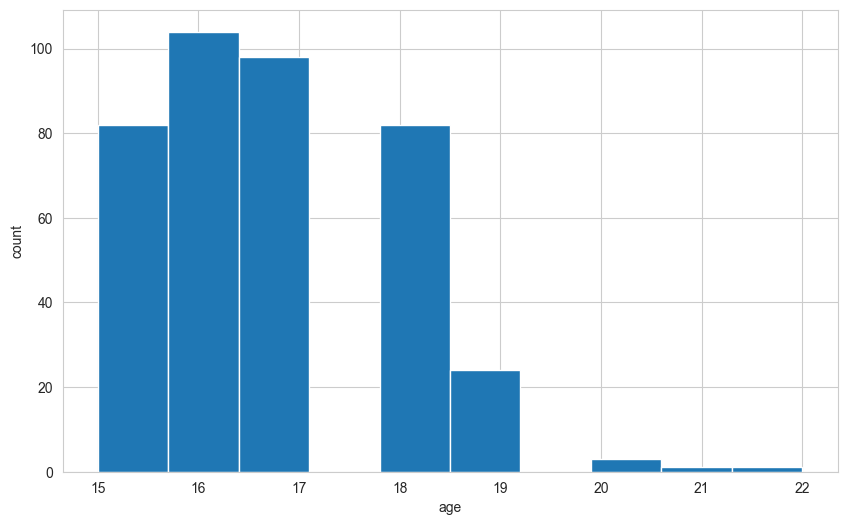

In [ ]:
plt.hist(student_data['age'])
plt.xlabel('age')
plt.ylabel('count')
plt.grid=(True)

In [ ]:
student_data.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [ ]:
student_data['studytime'].median()

np.float64(2.0)

In [ ]:
student_data['studytime'].mode()

0    2
Name: studytime, dtype: int64

In [ ]:
student_data['studytime'].var()

np.float64(0.7043243590567373)

In [ ]:
student_data['studytime'].std()

np.float64(0.8392403464185556)

TypeError: 'bool' object is not callable

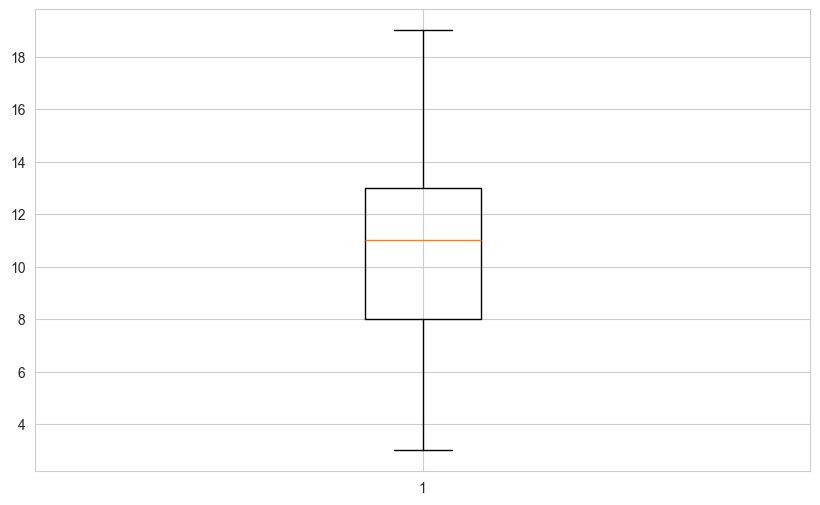

In [ ]:
plt.boxplot(student_data['G1'])
plt.grid(True)

True

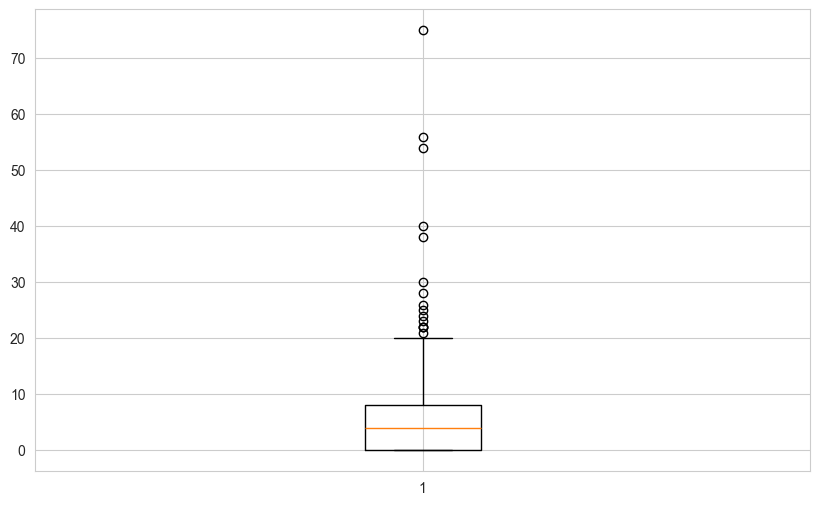

In [ ]:
plt.boxplot(student_data['absences'])
plt.grid

True

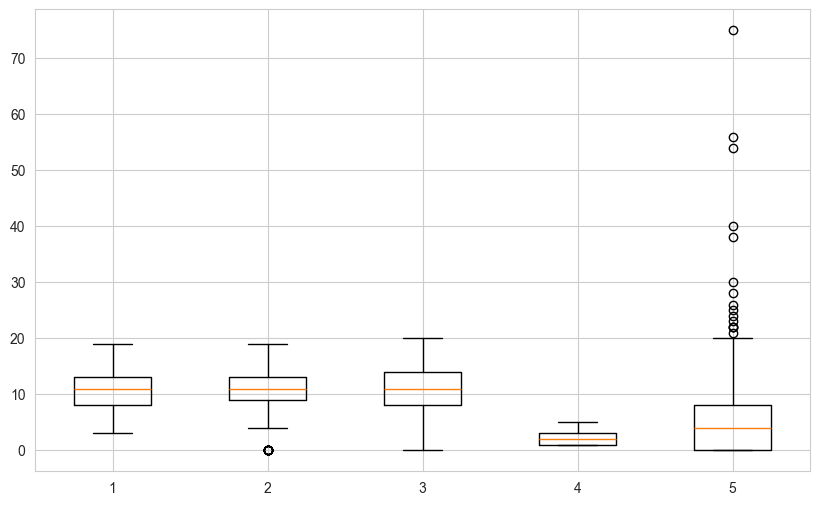

In [ ]:
plt.boxplot([student_data['G1'],student_data['G2'],student_data['G3'],student_data['Walc'],student_data['absences']])
plt.grid

In [ ]:
study_time_cv=student_data['studytime'].std()/student_data['studytime'].mean()
print(study_time_cv)

0.4123133542727978


In [ ]:
absences_cv=student_data['absences'].std()/student_data['absences'].mean()
print(absences_cv)

1.4018726369879073


In [ ]:
cv=student_data.std(numeric_only=True)/student_data.mean(numeric_only=True)
cv

age           0.076427
Medu          0.398177
Fedu          0.431565
traveltime    0.481668
studytime     0.412313
failures      2.225319
famrel        0.227330
freetime      0.308725
goout         0.358098
Dalc          0.601441
Walc          0.562121
health        0.391147
absences      1.401873
G1            0.304266
G2            0.351086
G3            0.439881
dtype: float64

In [ ]:
student_data.cov(min_periods=None,ddof=1,numeric_only=True)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
age,1.628285,-0.228619,-0.226949,0.062873,-0.004434,0.231221,0.061717,0.020947,0.180364,0.149039,0.192733,-0.110326,1.789501,-0.271413,-0.688653,-0.944612
Medu,-0.228619,1.198445,0.742717,-0.131061,0.059667,-0.192681,-0.003842,0.033779,0.078115,0.019341,-0.066440,-0.071349,0.878622,0.746135,0.887509,1.089096
Fedu,-0.226949,0.742717,1.184180,-0.120073,-0.008379,-0.202641,-0.001337,-0.013963,0.052220,0.002313,-0.017702,0.022303,0.213134,0.687245,0.674953,0.760078
traveltime,0.062873,-0.131061,-0.120073,0.486513,-0.059070,0.047844,-0.010512,-0.011861,0.022162,0.085941,0.120478,0.007274,-0.072255,-0.215402,-0.401940,-0.374337
studytime,-0.004434,0.059667,-0.008379,-0.059070,0.704324,-0.108321,0.029898,-0.120041,-0.059706,-0.146533,-0.274304,-0.088228,-0.421127,0.447401,0.428947,0.376110
failures,0.231221,-0.192681,-0.202641,0.047844,-0.108321,0.553017,-0.029564,0.068329,0.103123,0.090118,0.135964,0.068059,0.379265,-0.875557,-0.995528,-1.227932
famrel,0.061717,-0.003842,-0.001337,-0.010512,0.029898,-0.029564,0.803997,0.134974,0.064454,-0.061974,-0.130952,0.117252,-0.318287,0.065977,-0.061659,0.211000
freetime,0.020947,0.033779,-0.013963,-0.011861,-0.120041,0.068329,0.134974,0.997725,0.316944,0.185954,0.190163,0.105173,-0.464274,0.041817,-0.051764,0.051745
goout,0.180364,0.078115,0.052220,0.022162,-0.059706,0.103123,0.064454,0.316944,1.239388,0.264763,0.602744,-0.014824,0.394718,-0.550967,-0.679438,-0.677292
Dalc,0.149039,0.019341,0.002313,0.085941,-0.146533,0.090118,-0.061974,0.185954,0.264763,0.793420,0.742852,0.095579,0.797758,-0.278385,-0.214836,-0.223061


In [ ]:
np.cov(student_data['G1'],student_data['G3'])

array([[11.01705327, 12.18768232],
       [12.18768232, 20.9896164 ]])

In [ ]:
print(student_data['G1'].var())
print(student_data['G3'].var())

11.017053267364904
20.989616397866733


In [ ]:
student_data.corr(numeric_only=True)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
age,1.000000,-0.163658,-0.163438,0.070641,-0.004140,0.243665,0.053940,0.016434,0.126964,0.131125,0.117276,-0.062187,0.175230,-0.064081,-0.143474,-0.161579
Medu,-0.163658,1.000000,0.623455,-0.171639,0.064944,-0.236680,-0.003914,0.030891,0.064094,0.019834,-0.047123,-0.046878,0.100285,0.205341,0.215527,0.217147
Fedu,-0.163438,0.623455,1.000000,-0.158194,-0.009175,-0.250408,-0.001370,-0.012846,0.043105,0.002386,-0.012631,0.014742,0.024473,0.190270,0.164893,0.152457
traveltime,0.070641,-0.171639,-0.158194,1.000000,-0.100909,0.092239,-0.016808,-0.017025,0.028540,0.138325,0.134116,0.007501,-0.012944,-0.093040,-0.153198,-0.117142
studytime,-0.004140,0.064944,-0.009175,-0.100909,1.000000,-0.173563,0.039731,-0.143198,-0.063904,-0.196019,-0.253785,-0.075616,-0.062700,0.160612,0.135880,0.097820
failures,0.243665,-0.236680,-0.250408,0.092239,-0.173563,1.000000,-0.044337,0.091987,0.124561,0.136047,0.141962,0.065827,0.063726,-0.354718,-0.355896,-0.360415
famrel,0.053940,-0.003914,-0.001370,-0.016808,0.039731,-0.044337,1.000000,0.150701,0.064568,-0.077594,-0.113397,0.094056,-0.044354,0.022168,-0.018281,0.051363
freetime,0.016434,0.030891,-0.012846,-0.017025,-0.143198,0.091987,0.150701,1.000000,0.285019,0.209001,0.147822,0.075733,-0.058078,0.012613,-0.013777,0.011307
goout,0.126964,0.064094,0.043105,0.028540,-0.063904,0.124561,0.064568,0.285019,1.000000,0.266994,0.420386,-0.009577,0.044302,-0.149104,-0.162250,-0.132791
Dalc,0.131125,0.019834,0.002386,0.138325,-0.196019,0.136047,-0.077594,0.209001,0.266994,1.000000,0.647544,0.077180,0.111908,-0.094159,-0.064120,-0.054660


True

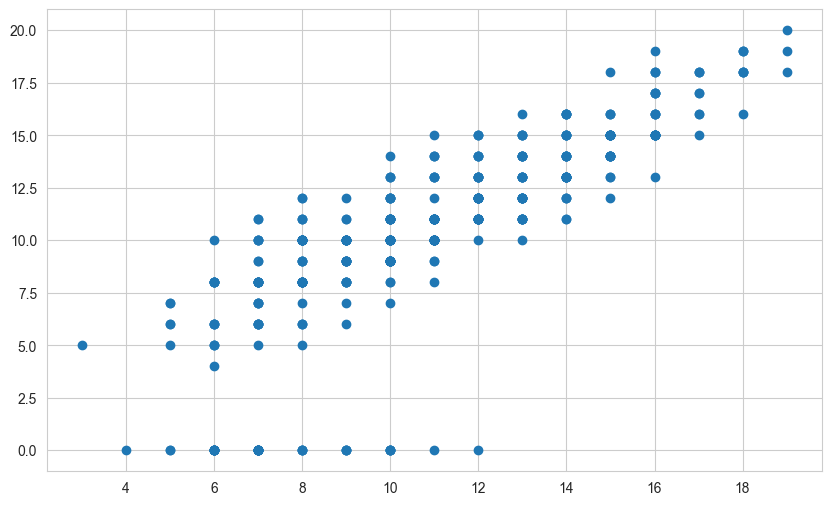

In [ ]:
plt.plot(student_data['G1'],student_data['G3'],'o')
plt.grid

True

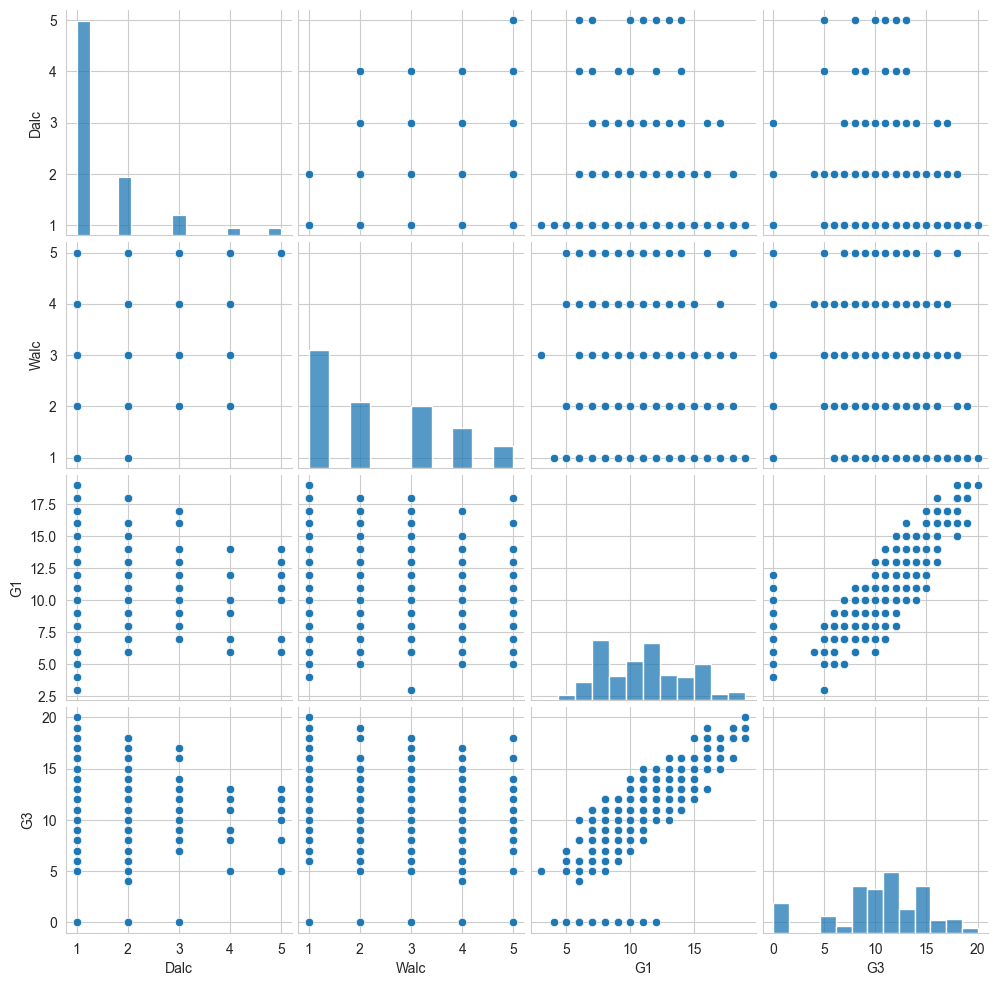

In [ ]:
sns.pairplot(student_data[['Dalc','Walc','G1','G3']])
plt.grid

In [ ]:
a=pd.read_csv('universities_ranking.csv')
a

,ranking,title,location,number students,students staff ratio,perc intl students,gender ratio
0,1,University of Oxford,United Kingdom,"20,774",11.1,41%,46 : 54
1,2,Stanford University,United States,"16,223",7.4,23%,44 : 56
2,3,Harvard University,United States,"21,261",9.3,25%,49 : 51
3,4,California Institute of Technology,United States,"2,238",6.3,33%,36 : 64
4,5,Massachusetts Institute of Technology,United States,"11,276",8.4,34%,39 : 61
...,...,...,...,...,...,...,...
1521,1522,Yuan Ze University,Taiwan,"8,188",19.7,7%,42 : 58
1522,1523,Yuriy Fedkovych Chernivtsi National University,Ukraine,"12,616",10.7,0%,57 : 43
1523,1524,Zagazig University,Egypt,"156,270",24.4,2%,54 : 46
1524,1525,University of Zagreb,Croatia,"59,336",15.3,3%,59 : 41


In [ ]:
a.isnull().sum()

ranking                  0
title                    0
location                 0
number students          0
students staff ratio     0
perc intl students       0
gender ratio            73
dtype: int64

In [ ]:
a.ffill

<bound method NDFrame.ffill of       ranking                                           title        location  \
0           1                            University of Oxford  United Kingdom   
1           2                             Stanford University   United States   
2           3                              Harvard University   United States   
3           4              California Institute of Technology   United States   
4           5           Massachusetts Institute of Technology   United States   
...       ...                                             ...             ...   
1521     1522                              Yuan Ze University          Taiwan   
1522     1523  Yuriy Fedkovych Chernivtsi National University         Ukraine   
1523     1524                              Zagazig University           Egypt   
1524     1525                            University of Zagreb         Croatia   
1525     1526                            University of Žilina        Slovakia 

In [ ]:
a.isnull().sum()

ranking                  0
title                    0
location                 0
number students          0
students staff ratio     0
perc intl students       0
gender ratio            73
dtype: int64

In [ ]:
a.dropna()

,ranking,title,location,number students,students staff ratio,perc intl students,gender ratio
0,1,University of Oxford,United Kingdom,"20,774",11.1,41%,46 : 54
1,2,Stanford University,United States,"16,223",7.4,23%,44 : 56
2,3,Harvard University,United States,"21,261",9.3,25%,49 : 51
3,4,California Institute of Technology,United States,"2,238",6.3,33%,36 : 64
4,5,Massachusetts Institute of Technology,United States,"11,276",8.4,34%,39 : 61
...,...,...,...,...,...,...,...
1521,1522,Yuan Ze University,Taiwan,"8,188",19.7,7%,42 : 58
1522,1523,Yuriy Fedkovych Chernivtsi National University,Ukraine,"12,616",10.7,0%,57 : 43
1523,1524,Zagazig University,Egypt,"156,270",24.4,2%,54 : 46
1524,1525,University of Zagreb,Croatia,"59,336",15.3,3%,59 : 41


In [ ]:
a.isnull().sum()

ranking                  0
title                    0
location                 0
number students          0
students staff ratio     0
perc intl students       0
gender ratio            73
dtype: int64

In [ ]:
import datetime as dt

In [ ]:
from datetime import date,datetime,time,timezone
datetime(2033,7,7)

datetime.datetime(2033, 7, 7, 0, 0)

In [ ]:
datetime(2021,7,7,15,50)

datetime.datetime(2021, 7, 7, 15, 50)

In [ ]:
dt.now()

AttributeError: module 'datetime' has no attribute 'now'

In [ ]:
datetime.now()

datetime.datetime(2026, 6, 23, 16, 24, 26, 120137)

In [ ]:
datetime.now(timezone.utc)

datetime.datetime(2026, 6, 23, 10, 55, 8, 393919, tzinfo=datetime.timezone.utc)

In [ ]:
datetime.now().date()

datetime.date(2026, 6, 23)

In [ ]:
datetime.now().time()

datetime.time(16, 25, 37, 146392)

In [ ]:
pandas.Timpestamp()

NameError: name 'pandas' is not defined

In [ ]:
pd.Timestamp

pandas.Timestamp

In [ ]:
pd.Timedelta


pandas.Timedelta

In [2]:
import pandas as pd
import numpy as np
import datetime
from datetime import date , datetime,time,timezone
datetime(2033,7,7)

datetime.datetime(2033, 7, 7, 0, 0)

In [62]:
datetime(2021,7,7,15,50)

datetime.datetime(2021, 7, 7, 15, 50)

In [63]:
d=date(2021,7,7)
t=time(13,26,10)
datetime.combine(d,t)

datetime.datetime(2021, 7, 7, 13, 26, 10)

In [64]:
datetime.now()

datetime.datetime(2026, 6, 24, 9, 10, 15, 790461)

In [65]:
datetime.now(timezone.utc)

datetime.datetime(2026, 6, 24, 3, 40, 49, 14664, tzinfo=datetime.timezone.utc)

In [66]:
datetime.now().date()

datetime.date(2026, 6, 24)

In [67]:
datetime.now().time()

datetime.time(9, 11, 20, 415313)

In [73]:
pd.Timestamp('2017-5-3-12:00')

Timestamp('2017-05-03 12:00:00')

In [74]:
pd.Timestamp('12:00')

Timestamp('2026-06-24 12:00:00')

In [76]:
mybirth=datetime(1973,7,7)
today=datetime.today()
tommorrow=today+pd.Timedelta(days=1)
print(tommorrow-mybirth)

19346 days, 9:18:05.990116


In [77]:
mybirth-today

datetime.timedelta(days=-19346, seconds=52914, microseconds=9884)

In [4]:
df1=pd.read_csv("DCOILWTICO.csv")

In [83]:
df1.head()

,observation_date,DCOILWTICO
0,2021-06-15,72.06
1,2021-06-16,72.03
2,2021-06-17,71.06
3,2021-06-18,71.64
4,2021-06-21,73.64


In [81]:
df1['observation_date']

0       2021-06-15
1       2021-06-16
2       2021-06-17
3       2021-06-18
4       2021-06-21
           ...    
1300    2026-06-09
1301    2026-06-10
1302    2026-06-11
1303    2026-06-12
1304    2026-06-15
Name: observation_date, Length: 1305, dtype: str

In [82]:
df1.info

<bound method DataFrame.info of      observation_date  DCOILWTICO
0          2021-06-15       72.06
1          2021-06-16       72.03
2          2021-06-17       71.06
3          2021-06-18       71.64
4          2021-06-21       73.64
...               ...         ...
1300       2026-06-09       91.90
1301       2026-06-10       93.68
1302       2026-06-11       91.58
1303       2026-06-12       88.62
1304       2026-06-15       84.65

[1305 rows x 2 columns]>

In [6]:
df1['N_DATE']=pd.to_datetime(df1['observation_date'])

In [7]:
df1['N_DATE']

0      2021-06-15
1      2021-06-16
2      2021-06-17
3      2021-06-18
4      2021-06-21
          ...    
1300   2026-06-09
1301   2026-06-10
1302   2026-06-11
1303   2026-06-12
1304   2026-06-15
Name: N_DATE, Length: 1305, dtype: datetime64[us]

In [8]:
df1.head()

,observation_date,DCOILWTICO,N_DATE
0,2021-06-15,72.06,2021-06-15
1,2021-06-16,72.03,2021-06-16
2,2021-06-17,71.06,2021-06-17
3,2021-06-18,71.64,2021-06-18
4,2021-06-21,73.64,2021-06-21


In [9]:
df=df1.drop(['observation_date'],axis=1)
df.head()

,DCOILWTICO,N_DATE
0,72.06,2021-06-15
1,72.03,2021-06-16
2,71.06,2021-06-17
3,71.64,2021-06-18
4,73.64,2021-06-21


In [10]:
df.set_index('N_DATE',inplace=True)
df.head()

,DCOILWTICO
N_DATE,
2021-06-15,72.06
2021-06-16,72.03
2021-06-17,71.06
2021-06-18,71.64
2021-06-21,73.64


In [11]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1305 entries, 2021-06-15 to 2026-06-15
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   DCOILWTICO  1249 non-null   float64
dtypes: float64(1)
memory usage: 20.4 KB


In [13]:
df['2016-11-04':'2021-6-15']

,DCOILWTICO
N_DATE,
2021-06-15,72.06


In [14]:
pd.date_range(start='2021-01-01',end=None,periods=5,freq='D',tz=None)

DatetimeIndex(['2021-01-01', '2021-01-02', '2021-01-03', '2021-01-04',
               '2021-01-05'],
              dtype='datetime64[us]', freq='D')

In [15]:
df.iloc[:10]

,DCOILWTICO
N_DATE,
2021-06-15,72.06
2021-06-16,72.03
2021-06-17,71.06
2021-06-18,71.64
2021-06-21,73.64
2021-06-22,73.15
2021-06-23,73.11
2021-06-24,73.31
2021-06-25,74.21


In [16]:
df['2021-10-15':]

,DCOILWTICO
N_DATE,
2021-10-15,82.39
2021-10-18,82.62
2021-10-19,83.19
2021-10-20,84.40
2021-10-21,82.64
...,...
2026-06-09,91.90
2026-06-10,93.68
2026-06-11,91.58


In [33]:
p_data=pd.period_range(start='2021-01-01',end='2021-12-31',periods=None,freq='M')
p_data

PeriodIndex(['2021-01', '2021-02', '2021-03', '2021-04', '2021-05', '2021-06',
             '2021-07', '2021-08', '2021-09', '2021-10', '2021-11', '2021-12'],
            dtype='period[M]')

In [20]:
for i in df:
    print(df[i])

N_DATE
2021-06-15    72.06
2021-06-16    72.03
2021-06-17    71.06
2021-06-18    71.64
2021-06-21    73.64
              ...  
2026-06-09    91.90
2026-06-10    93.68
2026-06-11    91.58
2026-06-12    88.62
2026-06-15    84.65
Name: DCOILWTICO, Length: 1305, dtype: float64


In [25]:
for i in df.head():
    print(i)

DCOILWTICO


In [34]:
for i in p_data:
    print("{0} {1}" .format(i.start_time,i.end_time))

2021-01-01 00:00:00 2021-01-31 23:59:59.999999
2021-02-01 00:00:00 2021-02-28 23:59:59.999999
2021-03-01 00:00:00 2021-03-31 23:59:59.999999
2021-04-01 00:00:00 2021-04-30 23:59:59.999999
2021-05-01 00:00:00 2021-05-31 23:59:59.999999
2021-06-01 00:00:00 2021-06-30 23:59:59.999999
2021-07-01 00:00:00 2021-07-31 23:59:59.999999
2021-08-01 00:00:00 2021-08-31 23:59:59.999999
2021-09-01 00:00:00 2021-09-30 23:59:59.999999
2021-10-01 00:00:00 2021-10-31 23:59:59.999999
2021-11-01 00:00:00 2021-11-30 23:59:59.999999
2021-12-01 00:00:00 2021-12-31 23:59:59.999999


In [35]:
import matplotlib.pyplot as plt
import yfinance as yf

In [36]:
start=datetime(2020,1,1)
end=datetime(2020,12,31)
sec=yf.download(tickers=['005930.KS'],start=start,end=end)
sec.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,005930.KS,005930.KS,005930.KS,005930.KS,005930.KS
Date,,,,,
2020-01-02,47372.843750,48059.406703,47201.203012,47630.304857,12993228
2020-01-03,47630.308594,48574.332728,47115.386339,48059.410473,15422255
2020-01-06,47630.308594,47716.128970,46857.925211,47115.386339,10278951
2020-01-07,47887.761719,48402.683888,47716.120996,47801.941357,10009778
2020-01-08,48745.968750,49260.890955,47973.585442,48231.046545,23501171


In [43]:
for i in range(0,len(df)):
    print(df.iloc[i:i+5,]).mean(),end==' '

            DCOILWTICO
N_DATE                
2021-06-15       72.06
2021-06-16       72.03
2021-06-17       71.06
2021-06-18       71.64
2021-06-21       73.64


AttributeError: 'NoneType' object has no attribute 'mean'

In [44]:
sec.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 248 entries, 2020-01-02 to 2020-12-30
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   (Close, 005930.KS)   248 non-null    float64
 1   (High, 005930.KS)    248 non-null    float64
 2   (Low, 005930.KS)     248 non-null    float64
 3   (Open, 005930.KS)    248 non-null    float64
 4   (Volume, 005930.KS)  248 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.6 KB


In [45]:
df.rolling(window=5).mean()

,DCOILWTICO
N_DATE,
2021-06-15,NaN
2021-06-16,NaN
2021-06-17,NaN
2021-06-18,NaN
2021-06-21,72.086
...,...
2026-06-09,95.562
2026-06-10,94.346
2026-06-11,93.296


In [48]:
ma5=sec['Close'].rolling(window=5).mean()
ma5.head(10)

Ticker,005930.KS
Date,
2020-01-02,NaN
2020-01-03,NaN
2020-01-06,NaN
2020-01-07,NaN
2020-01-08,47853.438281
2020-01-09,48437.015625
2020-01-10,49123.578906
2020-01-13,49895.962500
2020-01-14,50616.855469


Text(0, 0.5, 'close price')

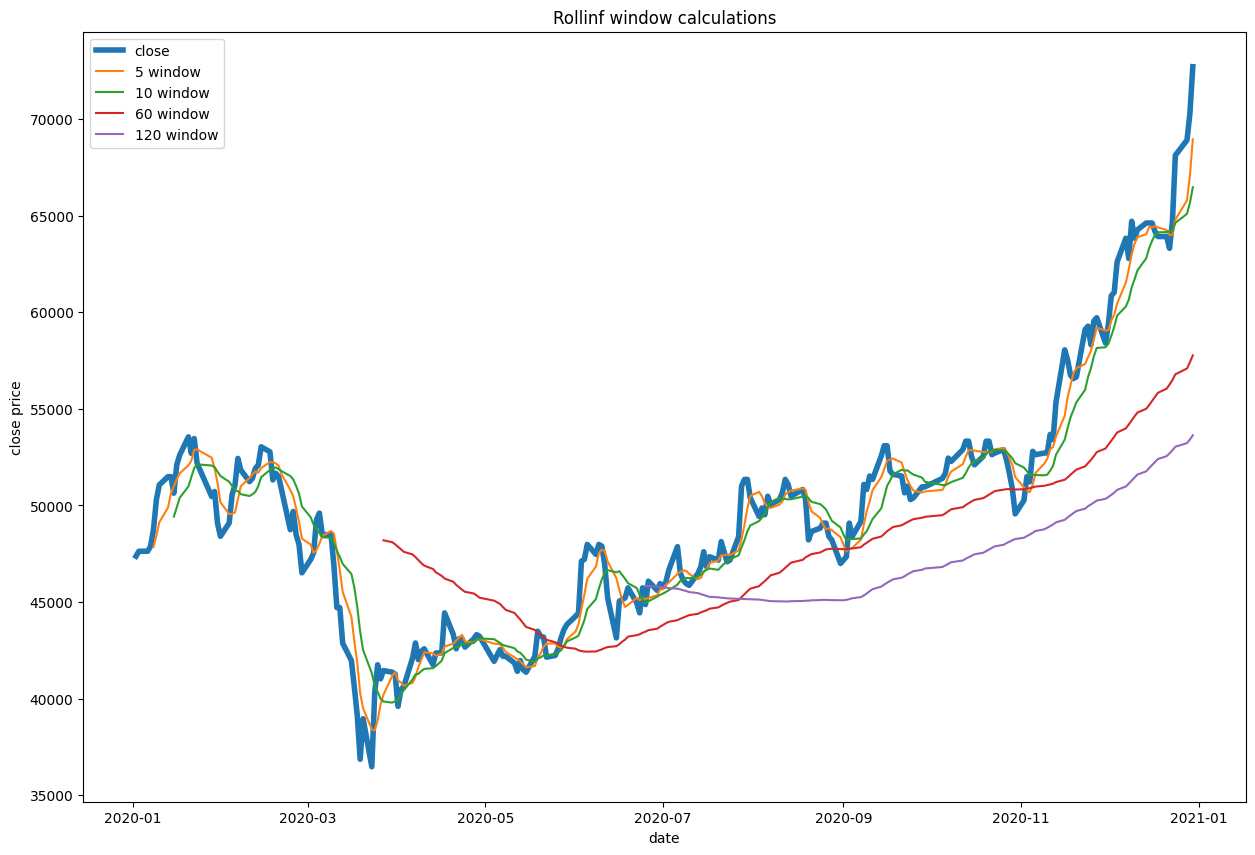

In [49]:
close=sec['Close']
ma5=sec['Close'].rolling(window=5).mean()
ma10=sec['Close'].rolling(window=10).mean()
ma60=sec['Close'].rolling(window=60).mean()
ma120=sec['Close'].rolling(window=120).mean()
plt.figure(figsize=(15,10))
plt.plot(close,label='close',linewidth=4)
plt.plot(ma5,label='5 window')
plt.plot(ma10,label='10 window')
plt.plot(ma60,label='60 window')
plt.plot(ma120,label='120 window')
plt.legend()
plt.title('Rollinf window calculations')
plt.xlabel('date')
plt.ylabel('close price')

In [50]:
df3=pd.read_csv('capture-fisheries-vs-aquaculture_tidytuesday.csv')

In [52]:
df3.head()

,Entity,Code,Year,Aquaculture production (metric tons),Capture fisheries production (metric tons)
0,Afghanistan,AFG,1969,60.0,400.0
1,Afghanistan,AFG,1970,60.0,400.0
2,Afghanistan,AFG,1971,60.0,500.0
3,Afghanistan,AFG,1972,60.0,500.0
4,Afghanistan,AFG,1973,60.0,500.0


In [54]:
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 14674 entries, 0 to 14673
Data columns (total 5 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Entity                                      14674 non-null  str    
 1   Code                                        11901 non-null  str    
 2   Year                                        14674 non-null  int64  
 3   Aquaculture production (metric tons)        11657 non-null  float64
 4   Capture fisheries production (metric tons)  14516 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 573.3 KB


In [55]:
df3.drop(['Code'],axis=1,inplace=True)

In [56]:
df3.head()

,Entity,Year,Aquaculture production (metric tons),Capture fisheries production (metric tons)
0,Afghanistan,1969,60.0,400.0
1,Afghanistan,1970,60.0,400.0
2,Afghanistan,1971,60.0,500.0
3,Afghanistan,1972,60.0,500.0
4,Afghanistan,1973,60.0,500.0


In [57]:
df3.isnull().sum()

Entity                                           0
Year                                             0
Aquaculture production (metric tons)          3017
Capture fisheries production (metric tons)     158
dtype: int64

In [60]:
change_value=0
df3.fillna(change_value,inplace=True)

,Entity,Year,Aquaculture production (metric tons),Capture fisheries production (metric tons)
0,Afghanistan,1969,60.0,400.0
1,Afghanistan,1970,60.0,400.0
2,Afghanistan,1971,60.0,500.0
3,Afghanistan,1972,60.0,500.0
4,Afghanistan,1973,60.0,500.0
...,...,...,...,...
14669,Zimbabwe,1965,0.0,2000.0
14670,Zimbabwe,1966,0.0,2000.0
14671,Zimbabwe,1967,0.0,2000.0
14672,Zimbabwe,1968,0.0,2000.0


In [61]:
df3.isnull().sum()

Entity                                        0
Year                                          0
Aquaculture production (metric tons)          0
Capture fisheries production (metric tons)    0
dtype: int64

In [62]:
df3['new_year']=pd.to_datetime(df3['Year'].astype(str),format='%Y')
df3.set_index('new_year', inplace=True)
df3.drop(['Year'],axis=1,inplace=True)
df3.head()

,Entity,Aquaculture production (metric tons),Capture fisheries production (metric tons)
new_year,,,
1969-01-01,Afghanistan,60.0,400.0
1970-01-01,Afghanistan,60.0,400.0
1971-01-01,Afghanistan,60.0,500.0
1972-01-01,Afghanistan,60.0,500.0
1973-01-01,Afghanistan,60.0,500.0


In [63]:
df3.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 14674 entries, 1969-01-01 to 1969-01-01
Data columns (total 3 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Entity                                      14674 non-null  str    
 1   Aquaculture production (metric tons)        14674 non-null  float64
 2   Capture fisheries production (metric tons)  14674 non-null  float64
dtypes: float64(2), str(1)
memory usage: 458.6 KB


In [64]:
new_df=df3.sort_index()
new_df.head()

,Entity,Aquaculture production (metric tons),Capture fisheries production (metric tons)
new_year,,,
1960-01-01,Central African Republic,0.0,2000.0
1960-01-01,Argentina,0.0,104732.0
1960-01-01,Saint Vincent and the Grenadines,0.0,400.0
1960-01-01,Turks and Caicos Islands,0.0,830.0
1960-01-01,Lebanon,0.0,2100.0


In [68]:
new_df['Entity']=new_df['Entity'].astype('category')
new_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 14674 entries, 1960-01-01 to 2018-01-01
Data columns (total 3 columns):
 #   Column                                      Non-Null Count  Dtype   
---  ------                                      --------------  -----   
 0   Entity                                      14674 non-null  category
 1   Aquaculture production (metric tons)        14674 non-null  float64 
 2   Capture fisheries production (metric tons)  14674 non-null  float64 
dtypes: category(1), float64(2)
memory usage: 374.6 KB


In [69]:
new_df['Entity'].value_counts()

Entity
Afghanistan                    59
Africa Eastern and Southern    59
Africa Western and Central     59
Albania                        59
Algeria                        59
                               ..
Serbia                         13
Saint Martin (French part)     12
Curacao                         8
Sint Maarten (Dutch part)       8
South Sudan                     7
Name: count, Length: 264, dtype: int64

In [70]:
g=new_df.groupby(['new_year'])

In [71]:
g.head()

,Entity,Aquaculture production (metric tons),Capture fisheries production (metric tons)
new_year,,,
1960-01-01,Central African Republic,0.000000e+00,2000.000
1960-01-01,Argentina,0.000000e+00,104732.000
1960-01-01,Saint Vincent and the Grenadines,0.000000e+00,400.000
1960-01-01,Turks and Caicos Islands,0.000000e+00,830.000
1960-01-01,Lebanon,0.000000e+00,2100.000
...,...,...,...
2018-01-01,Middle East & North Africa (excluding high inc...,2.060145e+06,3023863.297
2018-01-01,Thailand,8.908640e+05,1727179.000
2018-01-01,Nicaragua,2.946840e+04,54554.000


In [72]:
for key,group in g:
    print('+key:',key)
    print('+number:',len(group))
    print(group.head())
    print('\n')

+key: (Timestamp('1960-01-01 00:00:00'),)
+number: 232
                                      Entity  \
new_year                                       
1960-01-01          Central African Republic   
1960-01-01                         Argentina   
1960-01-01  Saint Vincent and the Grenadines   
1960-01-01          Turks and Caicos Islands   
1960-01-01                           Lebanon   

            Aquaculture production (metric tons)  \
new_year                                           
1960-01-01                                   0.0   
1960-01-01                                   0.0   
1960-01-01                                   0.0   
1960-01-01                                   0.0   
1960-01-01                                   0.0   

            Capture fisheries production (metric tons)  
new_year                                                
1960-01-01                                      2000.0  
1960-01-01                                    104732.0  
1960-01-01     

In [73]:
world_total=g.sum(numeric_only=True)

In [74]:
world_total.head()

,Aquaculture production (metric tons),Capture fisheries production (metric tons)
new_year,,
1960-01-01,19150871.0,2.760285e+08
1961-01-01,17848583.0,3.106441e+08
1962-01-01,18297227.0,3.424042e+08
1963-01-01,20460244.0,3.496285e+08
1964-01-01,22491831.0,3.947974e+08


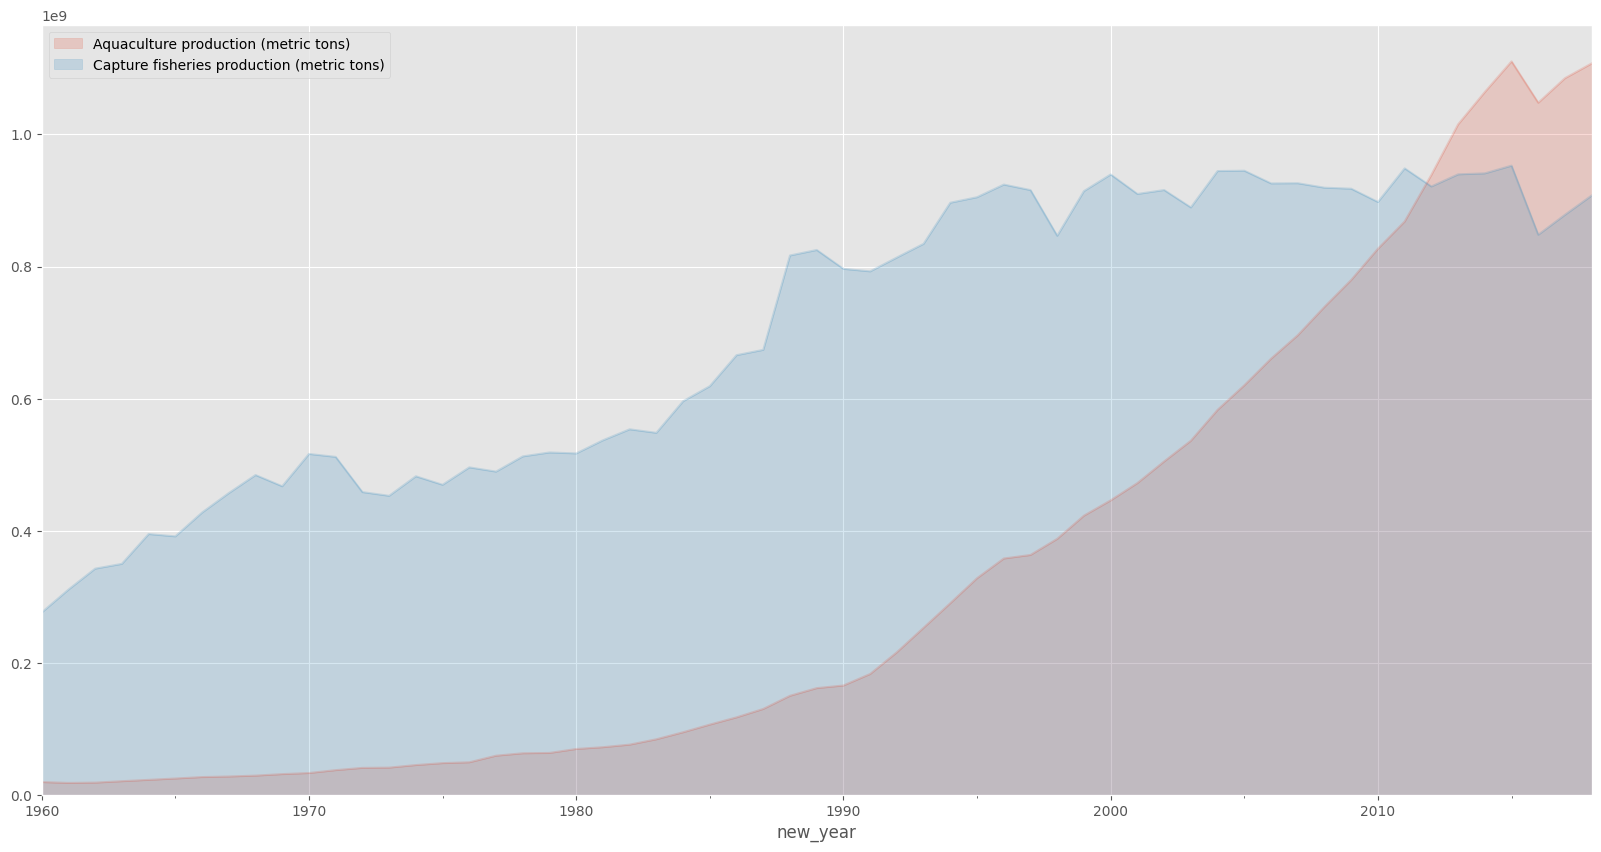

In [75]:
plt.style.use('ggplot')
world_total.plot(kind='area',alpha=0.2,stacked=False,figsize=(20,10))
plt.legend()
plt.show()


In [76]:
country=new_df['Entity'].value_counts()
print(country)
print('Data Type=>',type(country))

Entity
Afghanistan                    59
Africa Eastern and Southern    59
Africa Western and Central     59
Albania                        59
Algeria                        59
                               ..
Serbia                         13
Saint Martin (French part)     12
Curacao                         8
Sint Maarten (Dutch part)       8
South Sudan                     7
Name: count, Length: 264, dtype: int64
Data Type=> <class 'pandas.Series'>


In [77]:
'South Korea ' in country

False

In [97]:
s=new_df.loc[new_df['Entity']=='South Korea']
c=new_df.loc[new_df['Entity']=='China']
a=new_df.loc[new_df['Entity']=='Afghanistan']

In [98]:
s_y=s[['Aquaculture production (metric tons)','Capture fisheries production (metric tons)']]
s_x=s.index
c_y=c[['Aquaculture production (metric tons)','Capture fisheries production (metric tons)']]
c_x=c.index
a_y=a[['Aquaculture production (metric tons)','Capture fisheries production (metric tons)']]
a_x=a.index


Text(0.5, 0.98, 'FISH PRODUCTION')

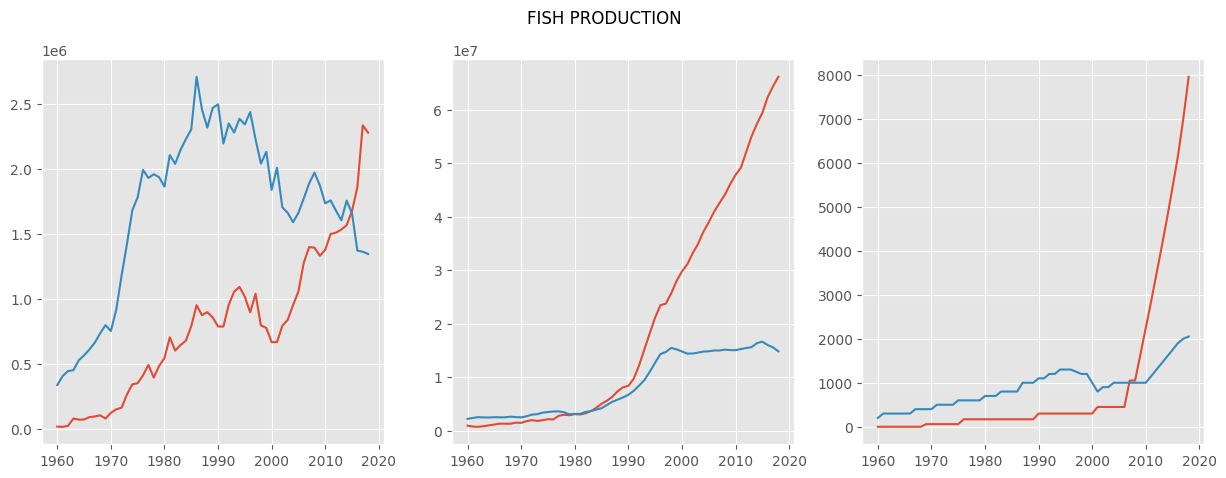

In [99]:
fig,axs=plt.subplots(1,3,figsize=(15,5))
axs[0].plot(s_x,s_y)
axs[1].plot(c_x,c_y)
axs[2].plot(a_x,a_y)
fig.suptitle("FISH PRODUCTION")